# Exploring directions opened up to us by random tokenization

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm

import sys
sys.path.append('..')

from pathlib import Path
import torch

In [2]:
from src.models.TTA_model import ClassifierWithTTA
from src.data.activity_data import ActivityGradientDataDict
from src.data.image_data import balanced_train_subsets

from omegaconf import OmegaConf

W1222 19:41:58.659000 31944 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


In [3]:
ckpt_dir = Path('../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints')

In [4]:
probe_model = ClassifierWithTTA.load_from_file(ckpt_dir / 'probe/best')
full_model = ClassifierWithTTA.load_from_file(ckpt_dir / 'full/best')

Successfully loaded weights from ../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/probe/best
Successfully loaded weights from ../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/full/best


#### Do the loaded models keep their settings?

Answer: no. They do not appear to have saved this setting. Probably because I didn't save the hyperparameters.

In [5]:
OmegaConf.load(ckpt_dir.parent/ '.hydra/config.yaml').model

{'classifier_hidden_layers': 2, 'randomized_CLS': True, 'hidden_dropout_prob': 0.2, 'attention_probs_dropout_prob': 0.2}

In [6]:
full_model.embedding.randomized_CLS

False

In [7]:
probe_model.embedding.randomized_CLS

False

## Learned embeddings - no randomization

The loaded model don't use randomization by default.

In [151]:
from src.models.TTA_model import ClassifierWithTTA
from src.data.image_data import balanced_train_subsets
ckpt_dir = Path('../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints')

probe_model = ClassifierWithTTA.load_from_file(ckpt_dir / 'probe/best')
full_model = ClassifierWithTTA.load_from_file(ckpt_dir / 'full/best')

Successfully loaded weights from ../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/probe/best
Successfully loaded weights from ../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/full/best


In [8]:
images_train, images_val = balanced_train_subsets(total_size=10000, train_fraction=0.)
probe_data = ActivityGradientDataDict(probe_model, probe_model.embedding.vit, images_train, images_val,
                                      device='mps')['val']
full_data = ActivityGradientDataDict(full_model, full_model.embedding.vit, images_train, images_val,
                                     device='mps')['val']

def output_cls_tokens(activity_data):
    outputs = []
    labels = []

    for batch in tqdm(iter(activity_data), total=10000 //8):
        activity, grad, label = batch
        outputs.append(activity[:, 0, :])
        labels.append(label)
    
    return torch.concat(outputs), torch.concat(labels)

In [9]:
full_model.embedding.randomized_CLS

False

In [10]:
probe_activity, probe_labels = output_cls_tokens(probe_data)
full_activity, full_labels = output_cls_tokens(full_data)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1250/1250 [03:04<00:00,  6.78it/s]


In [11]:
probe_activity = probe_activity.cpu()
full_activity = full_activity.cpu()

### Overall visualization

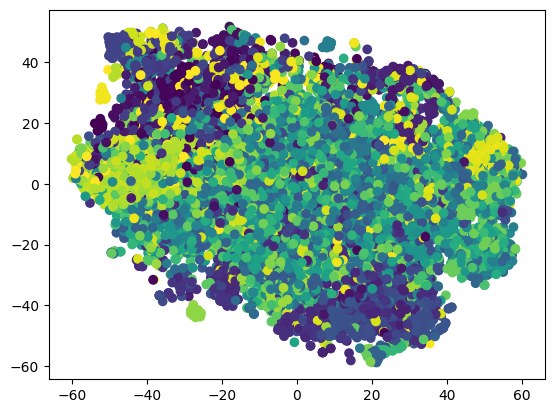

In [12]:
from sklearn.manifold import TSNE
tsne = TSNE(2, perplexity=50.)
t_results = tsne.fit_transform(probe_activity)
plt.scatter(t_results[:,0], t_results[:,1], c=probe_labels)

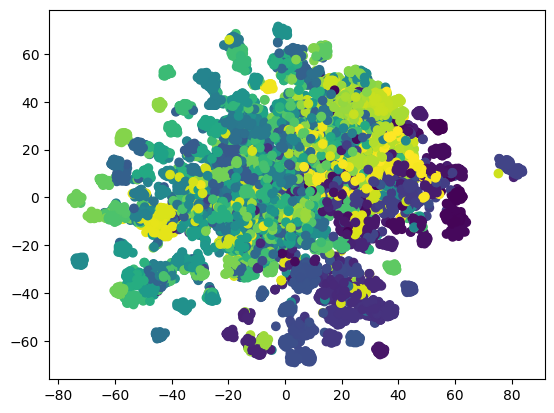

In [13]:
tsne = TSNE(2, perplexity=50.)
t_results = tsne.fit_transform(full_activity)
plt.scatter(t_results[:,0], t_results[:,1], c=full_labels)

They are certainly different.

It's hard to tell with this color scheme, but I suspect that same labels are closer to one-another, and form the discrete points that we see.

Note, however, that the decoder is itself a transformer, so simple descriptions of distance may not accurately capture the network's notion of distance. 

### Distances between embeddings

In [14]:
# split into two sets: compute centroids on the first
def split_and_centroid(activity, labels):
    centroids = torch.zeros(200, 768)
    tests = []
    output_labels = []

    for i in range(200):
        inds = torch.where(labels==i)[0]
        
        centroid = activity[ inds[0:25]].mean(0)
        centroids[i,:] = centroid

        tests.append( activity[inds[25:]])
        output_labels.extend( len(inds[25:])*[i])

    return centroids, torch.concat(tests), torch.tensor(output_labels)



In [15]:
centroids, tests, labels = split_and_centroid(full_activity, full_labels)

In [16]:
centroid_distances = torch.cdist(tests, centroids)

In [17]:
centroid_distances.shape

torch.Size([5000, 200])

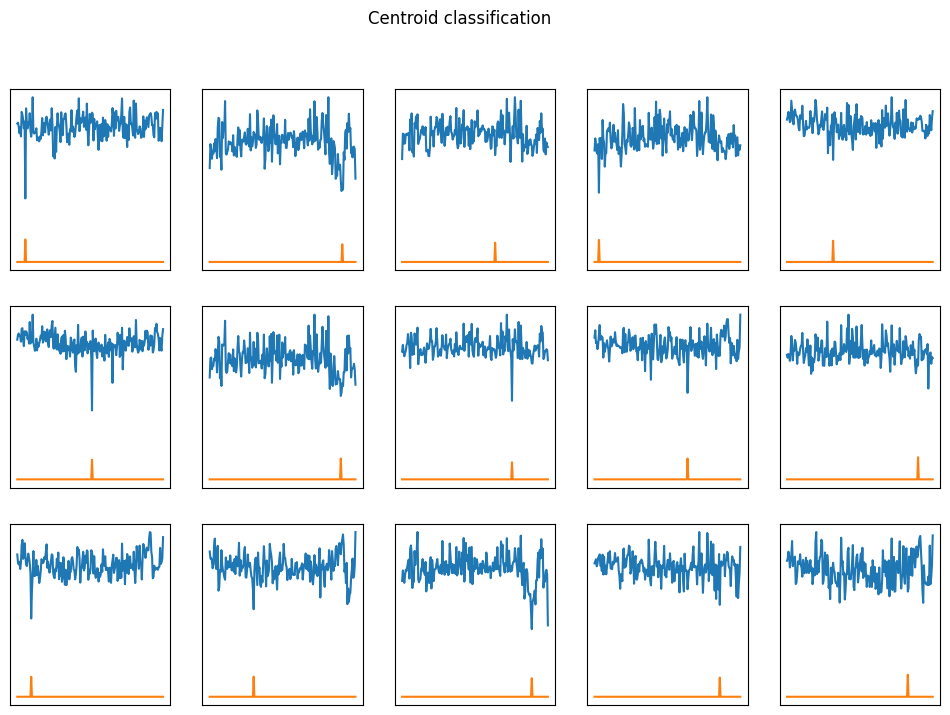

In [18]:
figsize(12,8)
plt.subplots(3,5)
plt.suptitle('Centroid classification')
for i in range(15):
    plt.subplot(3,5,i+1)
    ind = torch.randint(5000, (1,))[0]
    plt.plot(centroid_distances[ind,:])
    plt.plot(np.arange(200) == labels[ind])

    plt.xticks([]) 
    plt.yticks([]) 

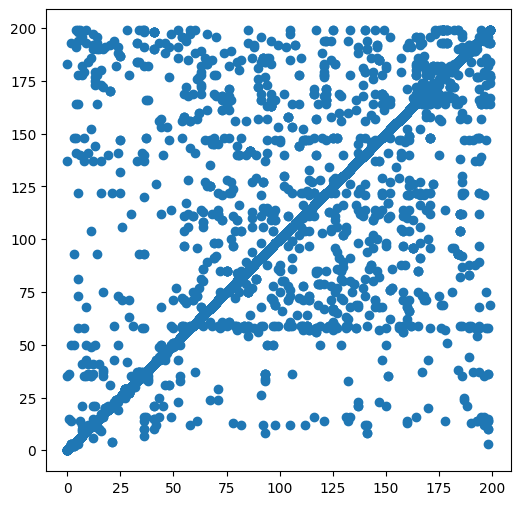

In [19]:
figsize(6,6)
plt.scatter(labels, centroid_distances.argmin(dim=1))

In [20]:
(labels == centroid_distances.argmin(dim=1)).sum() / len(labels)

tensor(0.7094)

Quite good performance based on distance to centroid. (actually, it's only 5% shy of the decoder itself...)

Not perfect, and there are some patterns that could be worth analyzing:
- the horizontal line around 55
- the cluster at the top left 

#### Same plots for untrained.

In [21]:
centroids, tests, labels = split_and_centroid(probe_activity, probe_labels)
centroid_distances = torch.cdist(tests, centroids)

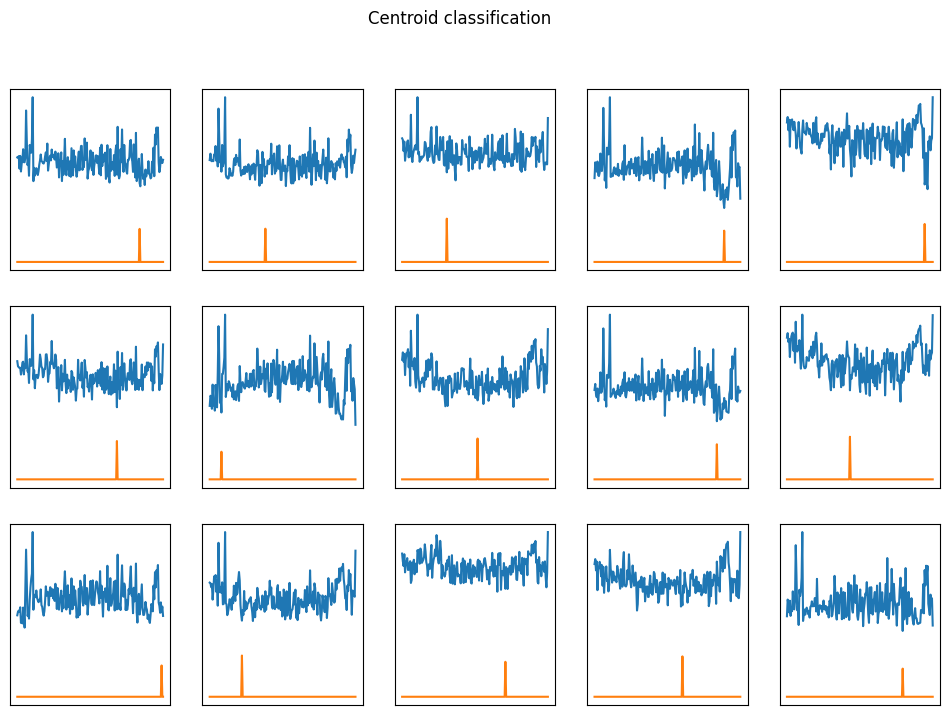

In [22]:
figsize(12,8)
plt.subplots(3,5)
plt.suptitle('Centroid classification')
for i in range(15):
    plt.subplot(3,5,i+1)
    ind = torch.randint(5000, (1,))[0]
    plt.plot(centroid_distances[ind,:])
    plt.plot(np.arange(200) == labels[ind])

    plt.xticks([]) 
    plt.yticks([]) 

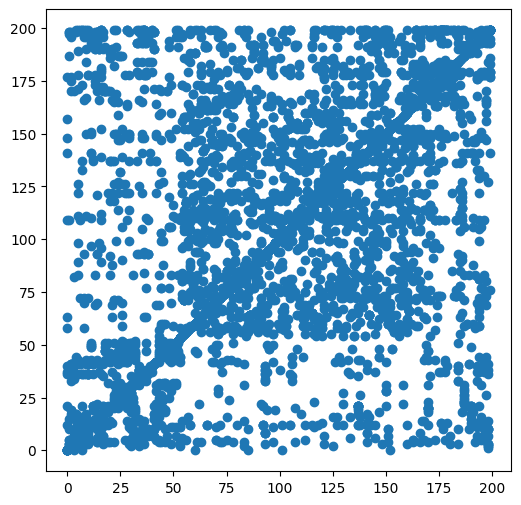

In [23]:
figsize(6,6)
plt.scatter(labels, centroid_distances.argmin(dim=1))

In [24]:
(labels == centroid_distances.argmin(dim=1)).sum() / len(labels)

tensor(0.3036)

Centroid approach still works ok for the probe-only training, but clearly it is substantially worse.

 - What I'm really looking for here is a way to visualize 'how concentrated' the distributions of labels are as we iterate. We would also need a way to fit the updated class distributions.

 - Another question that we can ask (later): what is the impact of resampling the cls token?

 - Note also: nothing that we have done here is specific to the resampled cls token. I suspect that the results will look the same regardless of CLS token distribution.


- Also, these embeddings do not use the randomized CLS tokens, so they don't show the influence of randomization.


## With randomization

Unfortunately, my older infrastructure is not built for this because I'm manually applying the steps of the encoder.

## Does CLS token randomization actually result in results 'spreading out?'

or does the network lean to contract the randomness?

### How diverse are the classification outputs?

In [152]:
ckpt_dir = Path('../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints')

probe_model = ClassifierWithTTA.load_from_file(ckpt_dir / 'probe/best')
full_model = ClassifierWithTTA.load_from_file(ckpt_dir / 'full/best')
probe_model.embedding.randomized_CLS = True
full_model.embedding.randomized_CLS = True

test_data, _ = balanced_train_subsets(train_fraction=1., split='valid')

Successfully loaded weights from ../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/probe/best
Successfully loaded weights from ../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/full/best


/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


In [67]:
full_model = full_model.to('mps')

In [83]:
outputs = []

for i in tqdm(range(len(test_data))):
    samples = full_model(test_data[i][0].unsqueeze(0).repeat((50,1,1,1)).to('mps')
                        ).logits.argmax(1).cpu()
    outputs.append({'unique': len(samples.unique()), 'mode': samples.mode().values.item(),
                    'gt': test_data[i][1].item(),
                    'includes_gt': (samples.unique() == test_data[i][1].item()).any()})

outputs = pd.DataFrame(outputs)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [1:31:12<00:00,  1.83it/s]


In [143]:
#post processing steps
outputs['includes_gt'] = outputs['includes_gt'].map(lambda x: x.item())
outputs['correct_mode'] = (outputs['mode'] == outputs['gt'])

In [144]:
outputs

,unique,mode,gt,includes_gt,correct_mode
0,1,0,0,True,True
1,1,0,0,True,True
2,1,0,0,True,True
3,1,0,0,True,True
4,2,4,0,False,False
...,...,...,...,...,...
9995,1,199,199,True,True
9996,1,199,199,True,True
9997,1,199,199,True,True
9998,1,62,199,False,False


In [145]:
outputs.to_csv('class_distribution.csv',index=False)

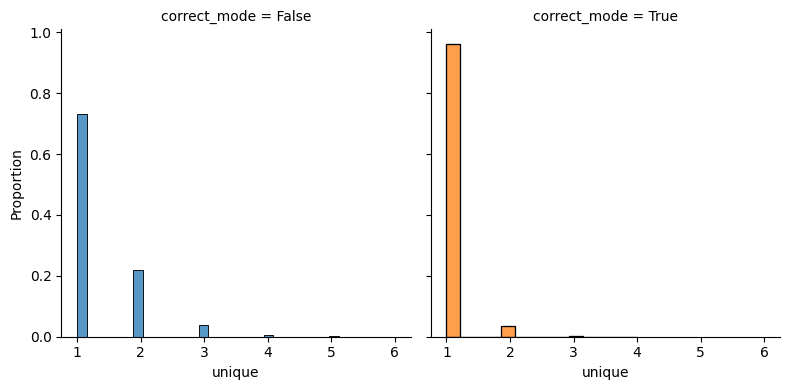

In [146]:
g = sns.FacetGrid(outputs, col="correct_mode",  hue='correct_mode', col_wrap=2, height=4)
g.map_dataframe( sns.histplot, x='unique', stat='proportion')

In most cases, there is only 1 decoded answer. This is even more the case for correct that incorrect answers.

<Axes: xlabel='unique', ylabel='Count'>

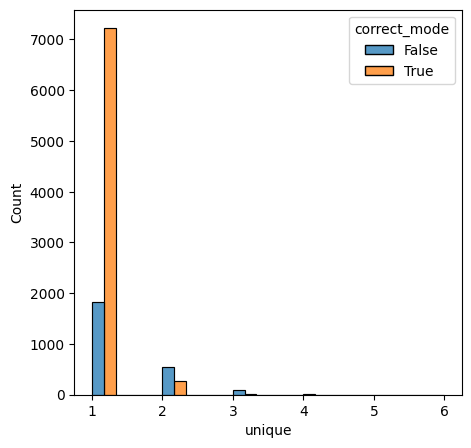

In [195]:
figsize(5,5)
sns.histplot(outputs, x='unique', hue='correct_mode', stat='count', multiple='dodge')

Most of examples with multiple decoded outputs have the incorrect mode.

<Axes: >

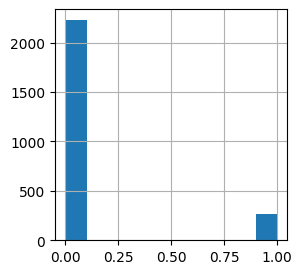

In [189]:
figsize(3,3)
outputs[~ outputs.correct_mode]['includes_gt'].map(int).hist()

In [175]:
outputs[~ outputs.correct_mode]['includes_gt'].sum() / len(outputs[~ outputs.correct_mode]['includes_gt'])

np.float64(0.10526315789473684)

Less promising: only 10% of the cases that produce the incorrect output include the ground truth. However, this neglects cases where there were multiple outputs but the ground truth was selected correctly.

<Axes: >

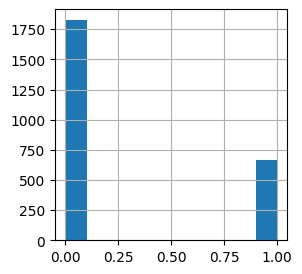

In [183]:
(outputs[~ outputs.correct_mode]['unique'] >1 ).map(int).hist()

In [190]:
(outputs[~ outputs.correct_mode]['unique'] >1 ).sum() / len(outputs[~ outputs.correct_mode]['unique'] >1 )

np.float64(0.26717557251908397)

26% of cases with multiple outputs include the correct ground truth as one of their samples.

In [193]:
outputs.correct_mode.sum() / len(outputs)

np.float64(0.7511)

In [196]:
outputs.includes_gt.sum() / len(outputs)

np.float64(0.7773)

Overall test accuracy is consistent with training. There is a small amount to be gained (~2%) by pass@100 over majority@100, but this is not sizable enough to worry much about.

In [123]:
outputs = pd.read_csv('class_distribution.csv')

<Axes: >

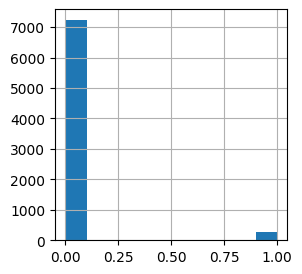

In [125]:
figsize(3,3)
(outputs[outputs.correct_mode]['unique'] >1 ).map(int).hist()

In [128]:
(outputs[outputs.correct_mode]['unique'] >1).sum() / len(outputs[outputs.correct_mode])

np.float64(0.03807748635334842)

Vice versa, there are very few multiple decodings when the answer is correct.

#### Overall,

This is promising. It is a fairly coarse measurement of variation (and one that's been trained against), but we still see that higher variation aligns with incorrect answers.

Less good is the relative sparsity of outputs that hit the correct answer in 100 samples. Also somewhat surprising is the fact that the number of different outputs sampled is limited to ~5 even with 100 samples.


## Embedding distribution

The question here is: how to find a measurement of spread that
1. direct: reflects the multiple decoding results
2. indirect: acts as a good certainty signal for later approaches

### Distribution of individual datapoints

If we want to use CLS token sampling as a means of enforcing a 'prior' over labels, then an important question is the distribution of predictions that the network produces.


#### Initial covariance exploration

In [525]:
outputs[10:20]

,unique,mode,gt,includes_gt,correct_mode
10,3,148,0,True,False
11,1,0,0,True,True
12,1,0,0,True,True
13,1,0,0,True,True
14,1,0,0,True,True
15,1,0,0,True,True
16,1,0,0,True,True
17,2,42,0,True,False
18,1,0,0,True,True
19,1,0,0,True,True


In [274]:
batch = test_data[11][0].unsqueeze(0).repeat((100,1,1,1)).to('mps')
pixel_values = full_model.preprocess(batch)
cls_embeddings = full_model.embedding.embedding(pixel_values)[:,0,:].detach().cpu()

In [275]:
from sklearn.covariance import OAS
oas = OAS().fit(cls_embeddings)
cov_shrink = oas.covariance_
eigvals = np.linalg.eigvalsh(cov_shrink)
logdet = np.sum(np.log(eigvals + 1e-32))
print(f'logdet: {logdet}', )
print('eigvals:', eigvals[-4:])

logdet: -3828.47607421875
eigvals: [0.4326185  0.5301801  0.69477123 0.8071691 ]


In [276]:
eigvals.sum()**2 / (eigvals**2).sum()

np.float32(60.627956)

Note that, as large negative numbers, the log det values reflect difference in determinants that are very close to zero. That makes sense: there is no variance in most dimensions.

The first eigenvalues also don't seem to show any pattern in their sizes. They seem to be all over the place.

Participation ratios don't change much either.

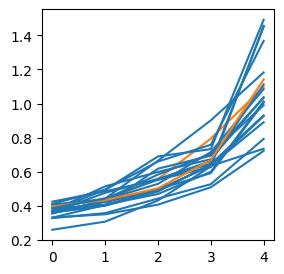

In [195]:
for ind in np.random.randint(0, 10000, 20):
    batch = test_data[ind][0].unsqueeze(0).repeat((100,1,1,1)).to('mps')
    pixel_values = full_model.preprocess(batch)
    cls_embeddings = full_model.embedding.embedding(pixel_values)[:,0,:].detach().cpu()

    oas = OAS().fit(cls_embeddings)
    cov_shrink = oas.covariance_
    eigvals = np.linalg.eigvalsh(cov_shrink)
    logdet = np.sum(np.log(eigvals + 1e-32))
    plt.plot(eigvals[-5:], c=f'C{int(outputs.loc[ind, 'unique']>1)}')

In [196]:
(cls_embeddings - cls_embeddings.mean(0)).abs().mean()

tensor(0.0637)

In [218]:
batch = test_data[18][0].unsqueeze(0).repeat((100,1,1,1)).to('mps')
pixel_values = full_model.preprocess(batch)
cls_embeddings = full_model.embedding.embedding(pixel_values)[:,0,:].detach().cpu()

In [219]:
from sklearn.metrics import pairwise_distances

In [220]:
pairwise_distances(cls_embeddings).mean()

np.float32(4.7204413)

If anything, the mean pairwise difference actually appears to be _smaller_ for cases with multiple decoding. This needs to be tested more carefully.

### Overall activity distribution

In [9]:
full_model.embedding.randomized_CLS = True
full_model = full_model.to('mps')

images_train, images_val = balanced_train_subsets(total_size=10000, train_fraction=0.)

In [26]:
def get_embedding(images, model=full_model):
    embeddings = []
    for batch in tqdm(torch.utils.data.DataLoader(images, batch_size=50, shuffle=False)):
        pixel_values = model.preprocess(batch[0])
        cls_embeddings = model.embedding.embedding(pixel_values.to('mps'))[:,0,:].detach().cpu()
        embeddings.append(cls_embeddings)

    return torch.concat(embeddings)

In [27]:
full_model.embedding.randomized_CLS

True

In [49]:
embeddings = get_embedding(images_val, model=full_model)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:51<00:00,  3.91it/s]


In [42]:
embeddings.shape 

torch.Size([10000, 768])

In [43]:
baseline = torch.randn(10000, 768)

In [44]:
(baseline - baseline.mean(0)).abs().mean()

tensor(0.7979)

In [45]:
(embeddings - embeddings.mean(0)).abs().mean()

tensor(0.1481)

Interestingly the mean absolute deviation seems to be _smaller_ than the baseline, indicating that network activity is, in some sense, _contracting_ the distribution

In [46]:
baseline.mean(0).abs().mean()

tensor(0.0083)

In [47]:
embeddings.mean(0).abs().mean()

tensor(0.1289)

However, the mean output _is_ sizably different from zero after mapping through the network.

In [50]:
embeddings2 = get_embedding(images_val, model=full_model)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:51<00:00,  3.85it/s]


In [53]:
(embeddings2 - embeddings2.mean(0)).abs().mean()

tensor(0.1481)

Curiously consistent between replicates.

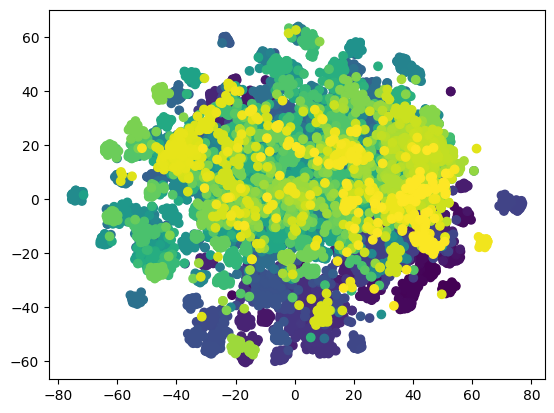

In [64]:
from sklearn.manifold import TSNE
tsne = TSNE(2, perplexity=50.)
t_results = tsne.fit_transform(embeddings)
plt.scatter(t_results[:,0], t_results[:,1], c=images_val[:][1])

This is similar to, but a bit less distinct than, the TSNE plot of the embeddings in the un-randomized case. The challenge here seems to be measureing the degree of 'clustering'

In [121]:
pairwise_distances(baseline).mean()

np.float32(39.176144)

In [122]:
pairwise_distances(embeddings).mean()

np.float32(8.166107)

This is even more pronounced for the mean pairwise difference: the neural network action _contracts_ the representation distances.

#### How do the pairwise distances compare within vs between labels?

In [304]:
dists = pairwise_distances(embeddings)
dists.mean()

np.float32(8.166107)

In [305]:
mask = np.ones((50,50), dtype=bool)
np.fill_diagonal(mask, False)

In [306]:
dists[0:50, 0:50][mask].mean()

np.float32(7.0902042)

In [308]:
dists[50:100, 50:100][mask].mean()

np.float32(6.4055142)

In [307]:
dists[0:50, 50:100].mean()

np.float32(7.7462783)

In [309]:
dists[0:50, 100:150].mean()

np.float32(7.759075)

There seems to be an effect on pairwise distances.

### Interim summary:

I thought that differences here would be easier to detect than multiple output decodings, but that does not appear to be the case. It's not a simple matter of wider spread -> multiple decodings. Instead, the decoding surface seems quite intricate (shouldn't be surprising with a transformer decoder). How else to detect missclassifications in an unsupervised way?

Ok, but then again, that is rather surprising to me. The centroid decoding works well. How can that be if the decoding surface is supposedly so tangled up?

In [129]:
labels = images_val[:][1]

In [131]:
labels.shape

torch.Size([10000])

#### One explaination for this behavior could be that learned embeddings are more 'space-filling'

In [163]:
torch.norm(baseline -baseline.mean(0), dim=1).mean()

tensor(27.7033)

In [164]:
torch.norm((embeddings - embeddings.mean(0)), dim=1).mean()

tensor(5.7682)

Indeed. The learned embeddings appear to be more space filling. 

In [172]:
torch.norm(embeddings[0:50] - embeddings[0:50].mean(0), dim=1).mean()

tensor(4.9516)

In [173]:
torch.norm(embeddings[200:250] - embeddings[200:250].mean(0), dim=1).mean()

tensor(4.8990)

In [240]:
print('multiple classes: ', torch.norm(embeddings[0:100] - embeddings[0:100].mean(0), dim=1).mean())

multiple classes:  tensor(5.1114)


Seems to be something of a weak signal for multiple decodings ~ uncertainty

In [292]:
batch = test_data[17][0].unsqueeze(0).repeat((100,1,1,1)).to('mps')
pixel_values = full_model.preprocess(batch)
cls_embeddings = full_model.embedding.embedding(pixel_values)[:,0,:].detach().cpu()

print(torch.norm(cls_embeddings - cls_embeddings.mean(0), dim=1).mean())

tensor(3.3995)


Again, fiddling by eye, there doesn't seem to be much signal here for individual samples.



#### Reflections:

Worth thinking about here: what do we want from an individual-point detector? Does that align with the goals of the project?

- individual points with TTA -> does the TTA align with CLS specific gradients / how to make them align?
- Note that this doesn't require detection per say. For that direction, we simply want a function of the multiple samples that uses the multiple sample output to ensure alignment between TTA gradients and classification gradients.

I was thinking about this direction in the context of my previous work: using the adaptation fixed-point as a sort of regularizer during finetuning. Knowing covert objectives ->  better objective preserving behavior.
- The main question there is _how_: how does knowing the loss function allow us to align our adaptation with it.
- Moreover, how can we do this with a single sample distribution?

This is getting to the core tension in my vision right now: what adaptation do I care about? Do I care about adaptation wrt different CLS token distributions or adaptation to different images / contexts? How does one relate to the other?

That's why this direction feels a bit tangential, despite it's apparent promise: why do I care about the CLS token distribution?

Restating, we care about _aligning_ TTA with the _covert_ objective of the layers. If covert objectives can be probed in some way by CLS token randomization, then this could be useful. Worth noting, the covert objectives will have something to do with the CLS tokens (they are the outputs) so this is not a terrible place to look.

## Can a neural network determine whether datapoints are correctly classified?

I mostly care about the full model at the moment.

### Deep sets approach

The idea here is essentially to learn sufficient statistics that are used to compare different distributions of points

In [2]:
from src.analysis.activity_analysis import DeepSets

W1212 13:19:14.445000 28549 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


In [3]:
activity_data = torch.load('../activity_data.pt')

In [15]:
weights = torch.load('./model_weights_full.pt')
model = DeepSets()
model.load_state_dict(weights)

<All keys matched successfully>

In [16]:
train_analysis = pd.DataFrame([
    {'pred': model( activity_data['activity'][i:i+1]).item(),
     'correct_cls': int((activity_data['gts'][i] == activity_data['predictions'][i].mode().values).item())
        }
    for i in tqdm(range(len(activity_data['activity'])))
])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:11<00:00, 8447.21it/s]


In [17]:
train_analysis['binary_pred'] = (train_analysis['pred'] > 0.5).astype(int)
train_analysis['correct_analysis'] = (train_analysis['correct_cls'] == train_analysis['binary_pred']).astype(int)

In [18]:
train_analysis

,pred,correct_cls,binary_pred,correct_analysis
0,0.999980,1,1,1
1,0.999836,1,1,1
2,0.982590,1,1,1
3,0.999983,1,1,1
4,1.000000,1,1,1
...,...,...,...,...
99995,0.999991,1,1,1
99996,1.000000,1,1,1
99997,1.000000,1,1,1
99998,0.201519,1,0,0


array([[<Axes: title={'center': 'correct_analysis'}>]], dtype=object)

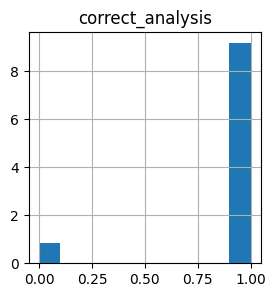

In [19]:
figsize(3,3)
train_analysis.hist(column='correct_analysis', density=True)

Predictions are good.

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

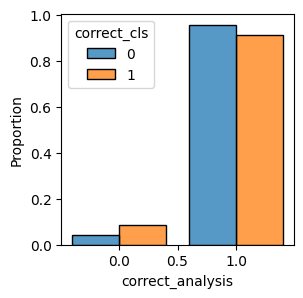

In [20]:
sns.histplot(
    train_analysis, 
    x='correct_analysis', 
    hue='correct_cls', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

Looks good: the model predicts both model successes and model errors equally well.

#### Test set

In [ ]:
activity_data_test = torch.load('./activity_data_test.pt')

In [22]:
test_analysis = pd.DataFrame([
    {'pred': model( activity_data_test['activity'][i:i+1]).item(),
     'correct_cls': int((activity_data_test['gts'][i] == activity_data_test['predictions'][i].mode().values).item())
        }
    for i in tqdm(range(len(activity_data_test['activity'])))
])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 7952.77it/s]


In [23]:
test_analysis['binary_pred'] = (test_analysis['pred'] > 0.5).astype(int)
test_analysis['correct_analysis'] = (test_analysis['correct_cls'] == test_analysis['binary_pred']).astype(int)

array([[<Axes: title={'center': 'correct_analysis'}>]], dtype=object)

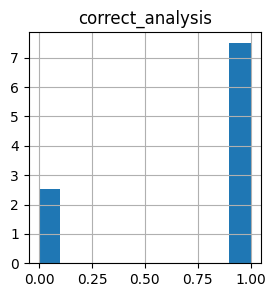

In [24]:
test_analysis.hist(column='correct_analysis', density=True)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

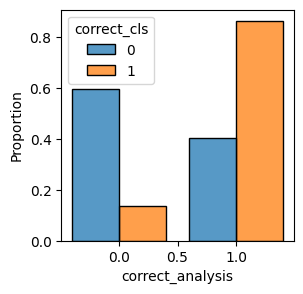

In [25]:
sns.histplot(
    test_analysis, 
    x='correct_analysis', 
    hue='correct_cls', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

Significantly worse performance on the test set. In fact, for incorrect answers, the analysis is more often than not incorrect.

Not good enough for our purposes. Essentially, this means that detection of incorrect answers does not generalize well to the test-set data. There is a bias toward classifying incorrect answers as correct. Maybe not surprising given that there are many more incorrect answers (~25%) in the test set.

This is an important point: the 'train' set was used for training both the classifier and the error-detector. Classification errors will therefore be low on this train set, resulting in a weak signal for the error detector to learn on, poor test performance.
- The ideal solution to this problem would be to divide the data up more evenly between these sets during training.

Moreover, I'm currently thinking that this direct classification approach might not be the right way to go. It makes sense if there are stereotypical ways that the CLS distribution changes when the answer is incorrect. If instead there are stereotypical correct distributions and many way for an incorrect distribution to look incorrect, then the task resembles anomaly detection more.

The previous point applies equally here: We want cls distributions for _correctly classified, non-train_ datapoints. It's very possible that the train datapoints show very different distributions than non-train ones.

### Out-of-the-box anomaly detection

Trying various techniques

In [3]:
from src.analysis.activity_analysis import DeepSets
activity_data = torch.load('../activity_data.pt')
activity_data_test = torch.load('./activity_data_test.pt')

weights = torch.load('./model_weights.pt')
model = DeepSets()
model.load_state_dict(weights)

W1212 15:51:19.310000 29726 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


<All keys matched successfully>

In [4]:
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

AD1 = OneClassSVM()
AD2 = IsolationForest()

In [5]:
correct_selector =  activity_data['predictions'].mode(1).values == activity_data['gts']

In [6]:
data = activity_data['activity'][correct_selector]
stats = model.phi( data).mean(1).detach().numpy()

In [7]:
AD2.fit(stats)

IsolationForest()

In [8]:
test_stats =  model.phi(activity_data_test['activity']).mean(1).detach().numpy()

In [15]:
(AD2.predict(test_stats) == 1).sum()

np.int64(8843)

In [9]:
results = pd.DataFrame({'analysis_predictions': (AD2.predict(test_stats) == 1).astype(int), 
              'actual': (activity_data_test['predictions'].mode(1).values ==  activity_data_test['gts']).to(int).numpy()
             })

In [10]:
results['correct_analysis'] = (results['analysis_predictions'] == results['actual']).astype(int)

In [18]:
results

,analysis_predictions,actual,correct_analysis
0,1,1,1
1,1,0,0
2,1,1,1
3,1,1,1
4,1,1,1
...,...,...,...
9995,1,1,1
9996,1,1,1
9997,0,0,1
9998,1,1,1


<Axes: xlabel='actual', ylabel='Count'>

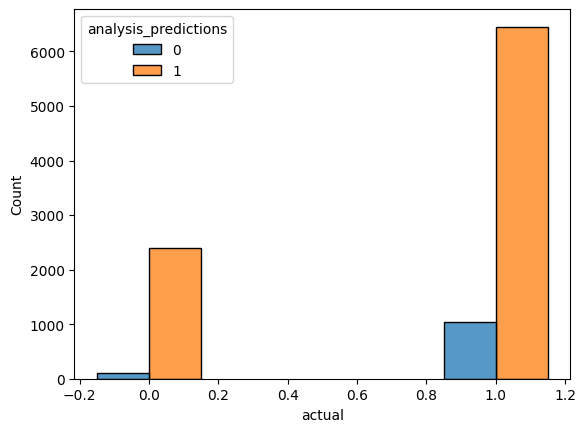

In [24]:
sns.histplot(results, x='actual', hue='analysis_predictions', discrete=True, multiple='dodge', shrink=0.3)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

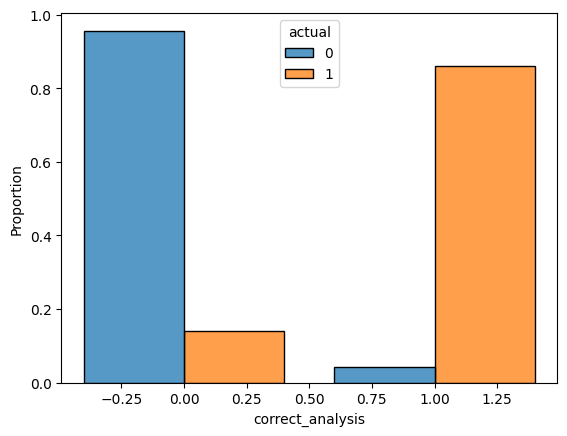

In [25]:
sns.histplot(
    results, 
    x='correct_analysis', 
    hue='actual', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

In [27]:
from pyod.models.ecod import ECOD
import numpy as np

# X should be shape (n_samples, n_features)
# for example: pooled means/vars of each 50×700 datapoint
# X = np.load("your_feature_matrix.npy")

clf = ECOD()
clf.fit(stats)

ECOD(contamination=0.1, n_jobs=1)

In [28]:
# anomaly scores (higher = more anomalous)
scores = clf.decision_scores_          # training data
test_scores = clf.decision_function(test_stats) # new data

# predicted labels: 0 = normal, 1 = anomaly
labels = clf.labels_
test_labels = clf.predict(test_stats)

In [29]:
test_labels

array([0, 0, 0, ..., 1, 1, 0], shape=(10000,))

In [32]:
results = pd.DataFrame({'analysis_predictions': 1-test_labels, 
              'actual': (activity_data_test['predictions'].mode(1).values ==  activity_data_test['gts']).to(int).numpy()
             })

<Axes: xlabel='actual', ylabel='Count'>

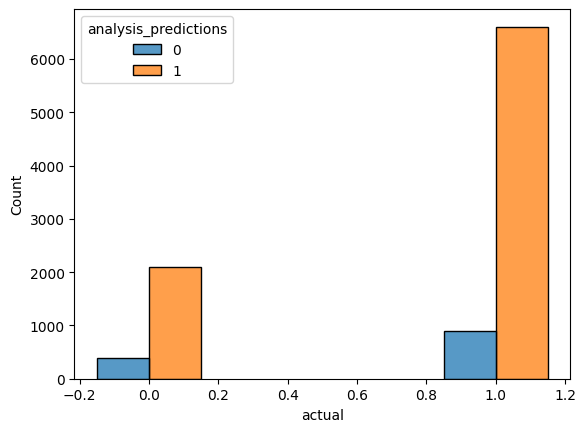

In [37]:
sns.histplot(results, x='actual', hue='analysis_predictions', discrete=True, multiple='dodge', shrink=0.3)

In [38]:
results['correct_analysis'] = (results['analysis_predictions'] == results['actual']).astype(int)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

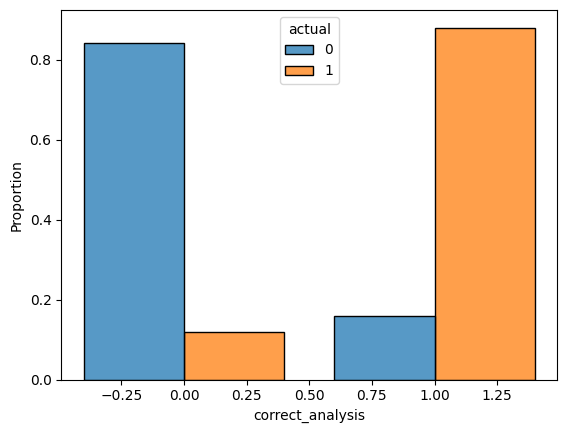

In [39]:
sns.histplot(
    results, 
    x='correct_analysis', 
    hue='actual', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

In [40]:
import numpy as np
from pyod.models.ecod import ECOD

# ---------------------------
# Pool each datapoint's distribution
# ---------------------------
# mean: shape (n_datapoints, dim)
means = data.mean(axis=1)

# variance: shape (n_datapoints, dim)
vars_ = data.var(axis=1)

# concat into one feature vector
X = np.concatenate([means, vars_], axis=1)  # shape (n_datapoints, 1400)

# ---------------------------
# Fit ECOD
# ---------------------------
clf = ECOD()
clf.fit(X)


ECOD(contamination=0.1, n_jobs=1)

In [41]:
# ---------------------------
# Pool each datapoint's distribution
# ---------------------------
# mean: shape (n_datapoints, dim)
means = activity_data_test['activity'].mean(axis=1)

# variance: shape (n_datapoints, dim)
vars_ = activity_data_test['activity'].var(axis=1)

# concat into one feature vector
X = np.concatenate([means, vars_], axis=1)  # shape (n_datapoints, 1400)

In [42]:
# anomaly scores
scores = clf.decision_scores_              # training scores
labels = clf.labels_                        # 0=normal, 1=anomaly

# predict on new data (same feature format)
test_scores = clf.decision_function(X)
test_labels = clf.predict(X)

print("Example anomaly scores:", scores[:10])
print("Example labels:", labels[:10])

Example anomaly scores: [2343.55546698 2430.66132024 2873.2882195  2527.82860911 2763.05564388
 2437.0762207  2544.05950331 2537.84672878 2480.141994   2621.69970186]
Example labels: [0 0 1 0 0 0 0 0 0 0]


In [43]:
results = pd.DataFrame({'analysis_predictions': 1-test_labels, 
              'actual': (activity_data_test['predictions'].mode(1).values ==  activity_data_test['gts']).to(int).numpy()
             })

<Axes: xlabel='actual', ylabel='Count'>

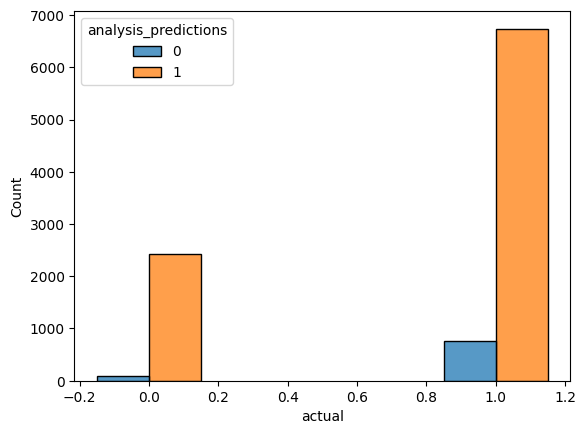

In [44]:
sns.histplot(results, x='actual', hue='analysis_predictions', discrete=True, multiple='dodge', shrink=0.3)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

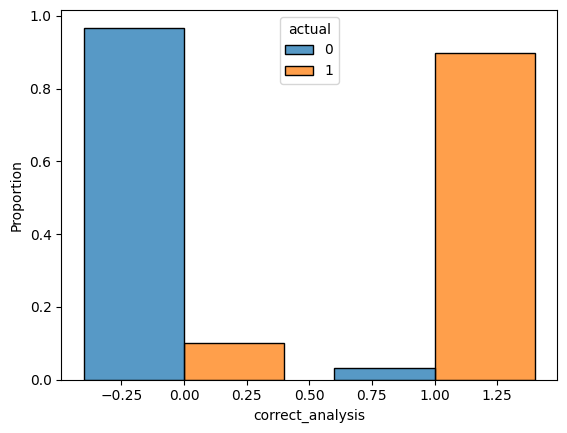

In [45]:
results['correct_analysis'] = (results['analysis_predictions'] == results['actual']).astype(int)
sns.histplot(
    results, 
    x='correct_analysis', 
    hue='actual', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

None of these off-the-shelf methods works very well. In fact, they are universally worse that the neural network approach.

### Continuing forward.

There is an important clue here in that the 'validation' performance for _analyzer_ training is quite good ~85%. This is about 10% better than the test set performance of the analyzer.

This indicates to me that there is a sizable contribution from the _classifier_ training points (which are mixed up between analyzer train and validation sets) in the validation performance, that is absent from the test performance (which contains no classifier train points).

Enforcing separation of the datasets might help our analyzer learn a signal that generalizes better.

### Neural network trained on classification validation set alone.

In [3]:
from src.analysis.activity_analysis import DeepSets

In [4]:
activity_data = torch.load('../activity_data.pt')

weights = torch.load('../model_weights.pt')
model = DeepSets()
model.load_state_dict(weights)

<All keys matched successfully>

#### Train

In [5]:
train_analysis = pd.DataFrame([
    {'pred': model( activity_data['activity'][i:i+1]).item(),
     'correct_cls': int((activity_data['gts'][i] == activity_data['predictions'][i].mode().values).item())
        }
    for i in tqdm(range(len(activity_data['activity'])))
])
train_analysis['binary_pred'] = (train_analysis['pred'] > 0.5).astype(int)
train_analysis['correct_analysis'] = (train_analysis['correct_cls'] == train_analysis['binary_pred']).astype(int)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 8543.82it/s]


array([[<Axes: title={'center': 'correct_analysis'}>]], dtype=object)

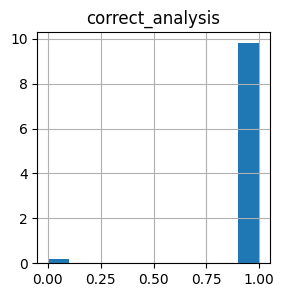

In [6]:
figsize(3,3)
train_analysis.hist(column='correct_analysis', density=True)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

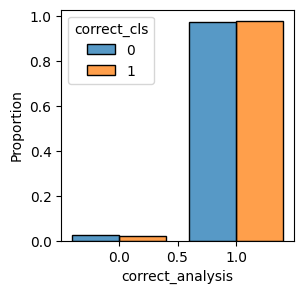

In [7]:
sns.histplot(
    train_analysis, 
    x='correct_analysis', 
    hue='correct_cls', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

#### Test analysis

In [8]:
activity_data_test = torch.load('./activity_data_test.pt')

test_analysis = pd.DataFrame([
    {'pred': model( activity_data_test['activity'][i:i+1]).item(),
     'correct_cls': int((activity_data_test['gts'][i] == activity_data_test['predictions'][i].mode().values).item())
        }
    for i in tqdm(range(len(activity_data_test['activity'])))
])
test_analysis['binary_pred'] = (test_analysis['pred'] > 0.5).astype(int)
test_analysis['correct_analysis'] = (test_analysis['correct_cls'] == test_analysis['binary_pred']).astype(int)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 9116.47it/s]


array([[<Axes: title={'center': 'correct_analysis'}>]], dtype=object)

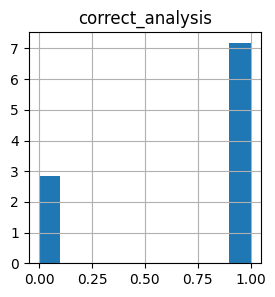

In [9]:
test_analysis.hist(column='correct_analysis', density=True)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

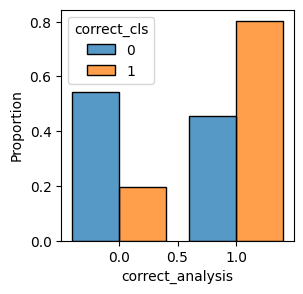

In [10]:
sns.histplot(
    test_analysis, 
    x='correct_analysis', 
    hue='correct_cls', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

No joy. Only very slightly better. This still lags the validation during training, but is closer.

###  Sanity check: What do these plots look like based on the decoding data only?

In [95]:
decoding_analysis = []

for i in range(len(activity_data_test['gts'])):
    preds = activity_data_test['predictions'][i]
    gt = activity_data_test['gts'][i]

    row = {}
    row['correct_cls'] = int(preds.mode().values == gt)
    row['binary_pred'] = int(len(preds.unique()) <= 1)

    decoding_analysis.append(row)

decoding_analysis = pd.DataFrame(decoding_analysis)
decoding_analysis['correct_analysis'] = (decoding_analysis['correct_cls'] == decoding_analysis['binary_pred']).astype(int)


array([[<Axes: title={'center': 'correct_analysis'}>]], dtype=object)

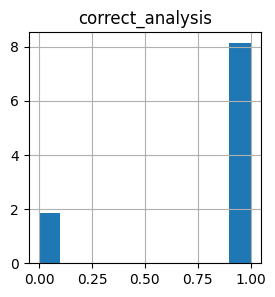

In [124]:
decoding_analysis.hist(column='correct_analysis', density=True)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

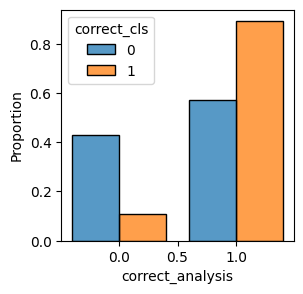

In [89]:
sns.histplot(
    decoding_analysis, 
    x='correct_analysis', 
    hue='correct_cls', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

OK! This is really nice to have: predicting based on just uniqueness of decoding is correct more often than not.

#### However, this does not agree with my previous analysis... 

- still 50 samples.

In [111]:
prev_analysis = pd.read_csv('class_distribution.csv')
prev_analysis['correct_mode'] = prev_analysis['correct_mode'].astype(int)
prev_analysis['prediction'] = (prev_analysis['unique'] <=1).astype(int)

prev_analysis['correct_analysis'] = (prev_analysis['prediction'] == prev_analysis['correct_mode']).astype(int)

<Axes: xlabel='correct_analysis', ylabel='Proportion'>

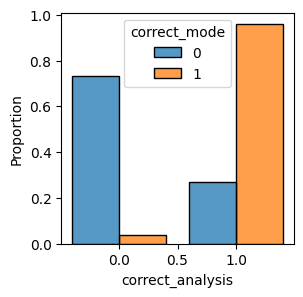

In [112]:
sns.histplot(
    prev_analysis, 
    x='correct_analysis', 
    hue='correct_mode', 
    multiple='dodge', 
    stat='proportion', 
    common_norm=False,
    discrete=True, 
    shrink=0.8 
)

In [126]:
prev_analysis['prediction'].mean()

np.float64(0.9049)

In [128]:
decoding_analysis['binary_pred'].mean()

np.float64(0.778)

The main difference here is that there appear to be more non-unique samples... Not sure why that is the case, I suspect that this may be a feature of different model loading or different cls sampling from rewrites in the model class.

Clearly I need to perform some more careful analyses.

#### Continuing
At the moment, however, this in-compatibility is not as important as the answer for the current model:
- for the current model, we __can__ do better than the models that we have been producing.
- Important note, however: the identity decoder _does_ have access to other information, in the form of the image tokens.

### Analysis of accuracy data

In [2]:
activity_data_val = torch.load('./activity_data_val.pt')
activity_data_test = torch.load('./activity_data_test.pt')

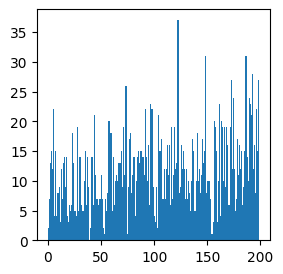

In [4]:
figsize(3,3)
correct_inds = activity_data_val['predictions'].mode().values == activity_data_val['gts']
incorrect = activity_data_val['gts'][~correct_inds]

counts_val, _, _=plt.hist(incorrect, bins=range(200))

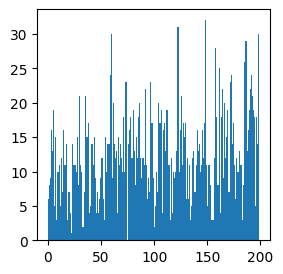

In [5]:
correct_inds = activity_data_test['predictions'].mode().values == activity_data_test['gts']
incorrect_test = activity_data_test['gts'][~correct_inds]

counts_test, _, _ =plt.hist(incorrect_test, bins=range(200))

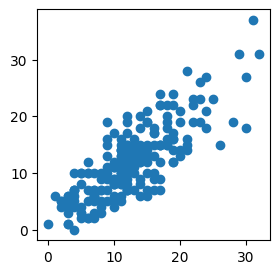

In [6]:
plt.scatter(counts_test, counts_val)

There appears to be a correlation between the numbers of incorrect answers for each class in the validation and test data. This is the sort correlation that the classifier might pick up on, unrelated to the shape of the point cloud. Note also that there are only _50_ samples per class in these datasets, so many of the classes are more wrong than right, which only enhances this argument.

### Trying out various modifications to the model

- no mean removal, no dropout: ~40% correct on cls failures
- no mean removal, dropout: ~50-50 on cls failures
    * interestingly, leaving dropout on, swaps the roles of the classes: 75% correct on cls failures, 40% correct on cls successes
- mean removal, no dropout: ~30% correct on cls failures
- mean removal, dropout: ~30% correct on cls failures.
    * as before, leaving dropout on, swaps the roles of the classes: 60% correct on cls failures, 40% correct on cls successes
- no mean removal, 50% dropout: finally better that 50% on the both classes in eval mode!
    * overall accuracy does suffer, due to error predictions on correct classifications
    * still 'swaps' when dropout is left on.
    * this is victory in a sense: the signal _is certainly_ there, overfitting was a big problem
- dropout 0.1 on $\phi$, 0.8 on $\rho$:
    * even stronger effect than above. Only 65% accuracy, but it performs very well on negative examples, at the cost of positive ones
    * same eval-off behavior, but sub 50% validation performance in this configuration

__Overall,__ this indicates that there is a good deal of overfitting happening in this model, that must be addressed. 
- notably, in these experiments, the test performance roughly tracks with validation performance, indicating that the dataset differences were important to fix.
- This can be seen in the good train performance on both correct and incorrect classifications.
- This can, of course, be helped by using more traing data, splitting a validation set out from the training at the beginning.
- Additionally, hyper-parameter sweep on dropout probabilities.


The swap when I leave dropout on is interesting, but can be exlained by a change from mostly positive predictions to mostly negative. Absent mean removal,
  * not in eval mode: predict 70% errors
  * in eval mode: predict 30% errors.
  * Why does that swap happen?



Below are plots of the dropout behavior:

In [19]:
# Plotting utilities
def analyze_model(model, dataset):
    analysis = pd.DataFrame([
        {'pred': model( dataset['activity'][i:i+1]).item(),
         'correct_cls': int((dataset['gts'][i] == dataset['predictions'][i].mode().values).item())
            }
        for i in range(len(dataset['activity']))
    ])
    analysis['binary_pred'] = (analysis['pred'] > 0.5).astype(int)
    analysis['correct_analysis'] = (analysis['correct_cls'] == analysis['binary_pred']).astype(int)
    
    return analysis


def make_row(analysis, name, subfig):
    subfig.suptitle(f'{name} data')
    axs = subfig.subplots(nrows=1, ncols=2)
    analysis.hist(column='correct_analysis', density=True, ax=axs[0])
    sns.histplot(analysis, x='correct_analysis', hue='correct_cls', 
        multiple='dodge', stat='proportion', common_norm=False, discrete=True, 
        shrink=0.8, ax=axs[1] 
    )


def make_plots(model, train_data, test_data, suptitle=''):
    train_analysis = analyze_model(model, train_data)
    test_analysis = analyze_model(model, test_data)
    fig = plt.Figure(layout='constrained', figsize=(6,7))
    subfigs = fig.subfigures(nrows=2, ncols=1)
    fig.suptitle(suptitle)
    make_row(train_analysis, 'Train', subfigs[0])
    make_row(test_analysis, 'test', subfigs[1])

    display(fig)

In [5]:
from src.analysis.activity_analysis import DeepSets

W1217 14:24:56.330000 87353 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


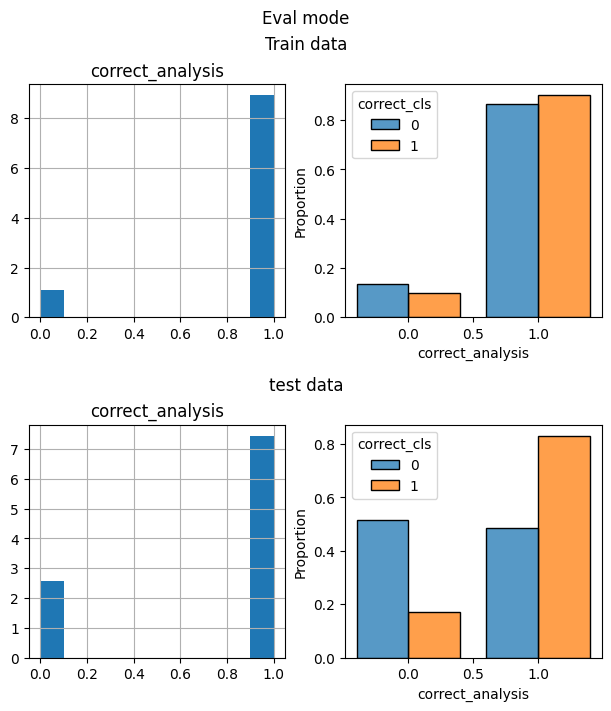

In [6]:
model = DeepSets.load_from_checkpoint('./dropoutmodel.ckpt').to('cpu')
model = model.eval()
make_plots(model, activity_data_val, activity_data_test, 'Eval mode')

Not the best performance, just for context.

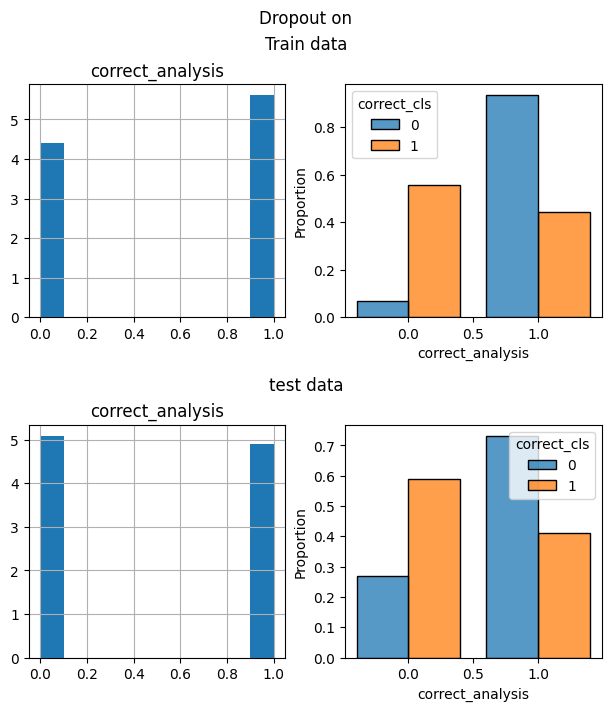

In [7]:
model = DeepSets.load_from_checkpoint('./dropoutmodel.ckpt').to('cpu')
make_plots(model, activity_data_val, activity_data_test, 'Dropout on')

Leaving dropout on results in a similary behavior on both train and val sets: mostly incorrect predictions, especially for correct classifications.

This corresponds to a switch from ~70% positive predictions to ~30% positive predictions when dropout was turned on.

### Following up this interesting 'accuracy swap' behavior

This is unlike what I've previously seen from leaving dropout on. Usually, since the the model was trained with dropout, the validation output with and without dropout active look fairly similar, with some noise riding on top of the dropout curves. After all, the model was trained with dropout active.

My hypothesis is that the prediction of many incorrect classifications with dropout on, is the result of the classification essentially reflecting a division between 'normal' and 'abnormal' point clouds. In this sense, dropout destroys 'normalness', and results more abnormal = error classifications. This section is dedicated to probing this hypothesis.

#### Does it still happen absent phi network dropout?

This would indicate that the behavior is __not__ the result of Deepsets specifics.

Answer: dropout in the rho network (the classifier on the output statistics) is sufficient (and necessary) to produce the inversion behavior. Not specific to Deepsets details.  

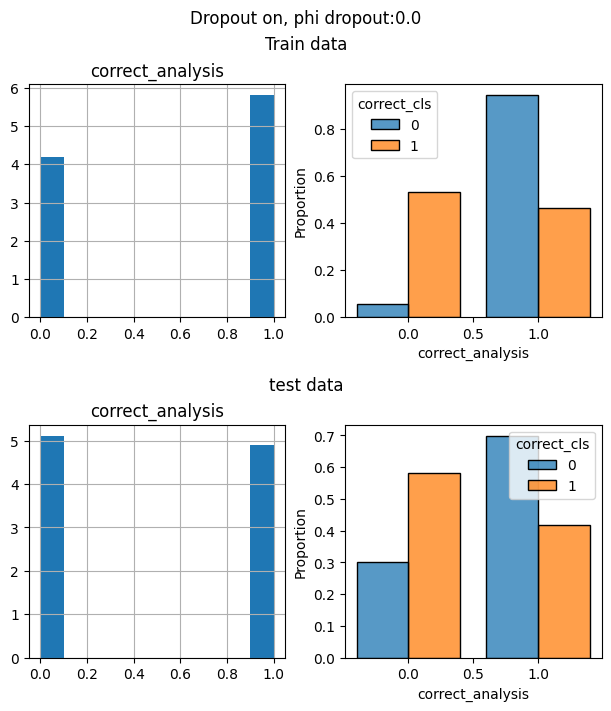

In [202]:
from src.analysis.activity_analysis import DeepSets
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')

make_plots(model, activity_data_val, activity_data_test, f'Dropout on, phi dropout:{model.phi.net[4].p}')

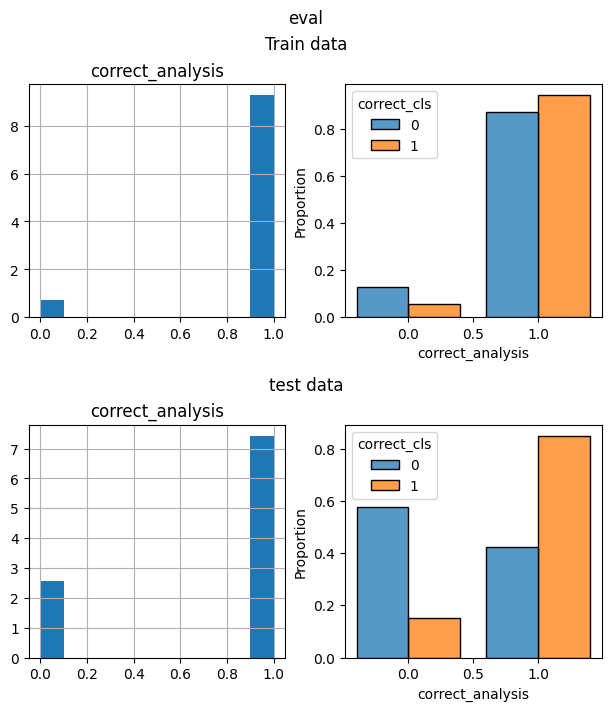

In [203]:
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')
model = model.eval()
make_plots(model, activity_data_val, activity_data_test, 'eval')

In [204]:
model

DeepSets(
  (phi): MLP(
    (net): Sequential(
      (0): Linear(in_features=768, out_features=256, bias=True)
      (1): Dropout(p=0.0, inplace=False)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): Dropout(p=0.0, inplace=False)
    )
  )
  (rho): MLP(
    (net): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Dropout(p=0.5, inplace=False)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): Dropout(p=0.5, inplace=False)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=1, bias=True)
      (7): Dropout(p=0.5, inplace=False)
    )
  )
  (loss): BCELoss()
)

True


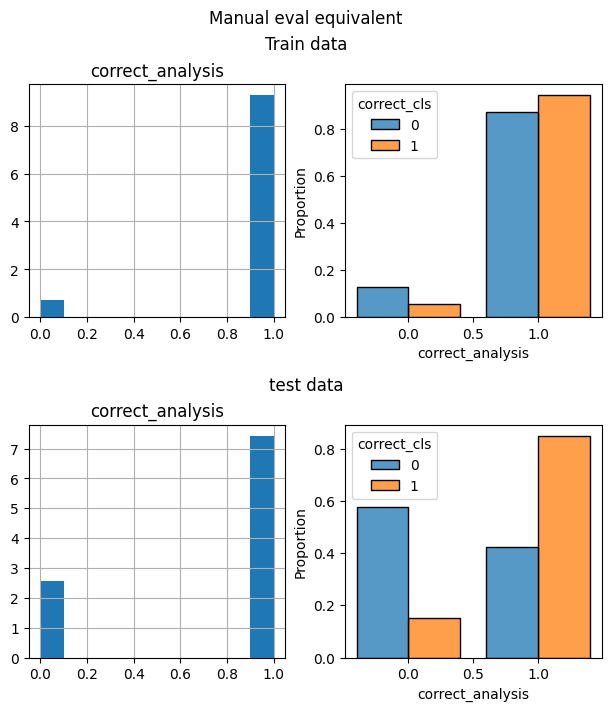

In [205]:
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')
model.rho.net[1].p = 0.0
model.rho.net[4].p = 0.0
model.rho.net[7].p = 0.0
print(model.training)

make_plots(model, activity_data_val, activity_data_test, 'Manual eval equivalent')

1. The behavior persists even with no dropout in the phi network.
2. Manually disabling rho dropout layers gives the same result as eval mode.

This indicates that the interesting behavior __does not__ result from set-statistic- or pooling- specific behaviors. It also __does not__ result from any other side-effects of eval mode.

(Again, not a stellar network performance-wise, but we're more interested in performance changes)


#### Brief finding on raw activity distributions

In [87]:
activity = activity_data_test['activity']
correct_labels = (activity_data_test['predictions'].mode().values == activity_data_test['gts'])

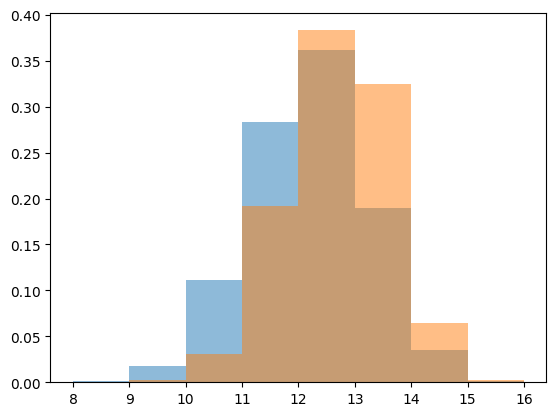

In [88]:
raw_cov_trs = torch.tensor([activity[i].T.cov().trace() for i in range(len(activity))])
plt.hist(raw_cov_trs[correct_labels], bins=range(8,17), density=True, alpha=0.5)
_=plt.hist(raw_cov_trs[~correct_labels], bins=range(8,17), density=True, alpha=0.5)

I guess this is something I never checked out before: another weak signal in the raw activity data. 

#### Testing normal vs abnormal:

In [6]:
activity = activity_data_test['activity']
correct_labels = (activity_data_test['predictions'].mode().values == activity_data_test['gts'])

In [7]:
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')
model = model.eval()

eval_logits = model.forward(activity_data_test['activity']).detach()

In [8]:
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')

samples = []
for rep in range(50):
    samples.append( model.forward(activity_data_test['activity']).detach())

samples = torch.stack(samples)

In [9]:
dropout_var = samples.var(0)
dropout_mean = samples.mean(0)

Text(0, 0.5, 'dropout mean')

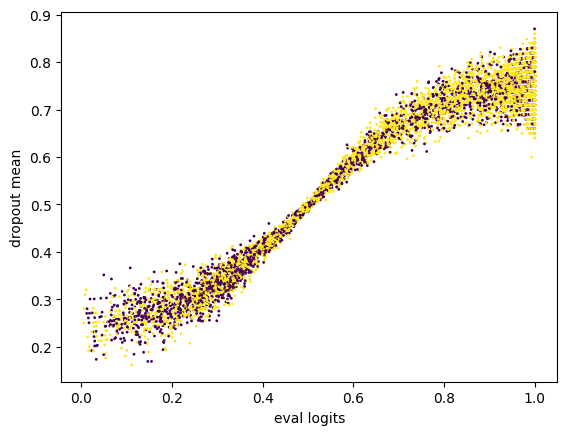

In [10]:
plt.scatter(eval_logits, dropout_mean, c=correct_labels, s=1)
plt.xlabel('eval logits')
plt.ylabel('dropout mean')

- dropout mean tracks evaluation fairly well.
- it is difficult to see the density change with label.

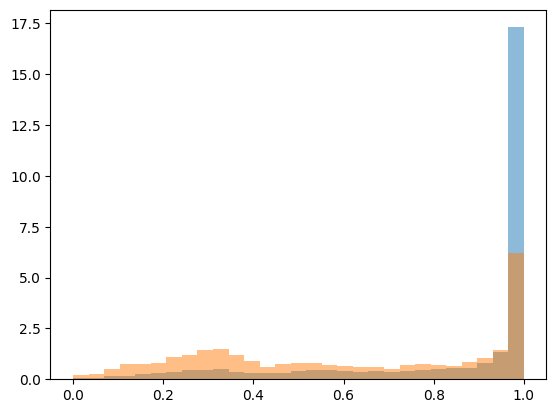

In [11]:
plt.hist(eval_logits[correct_labels], bins=np.linspace(0,1,30), alpha=0.5, density=True)
_=plt.hist(eval_logits[~correct_labels], bins=np.linspace(0,1,30), alpha=0.5, density=True)

Interesting: there is a shared tendency to  map to large logits. Negative values are simply slightly less concentrated in this way.

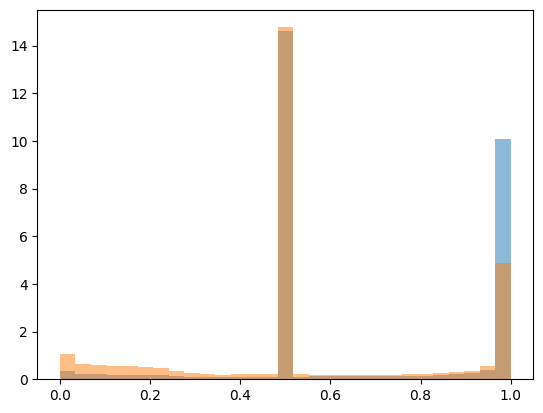

In [12]:
_=plt.hist(samples[:, correct_labels].view(-1), bins=np.linspace(0,1,30), alpha=0.5, density=True)
_=plt.hist(samples[:, ~correct_labels].view(-1), bins=np.linspace(0,1,30), alpha=0.5, density=True)

Emergence of a preponderance of results _exactly_ at 50%, on the classification boundary. 

Text(0, 0.5, 'sample variance')

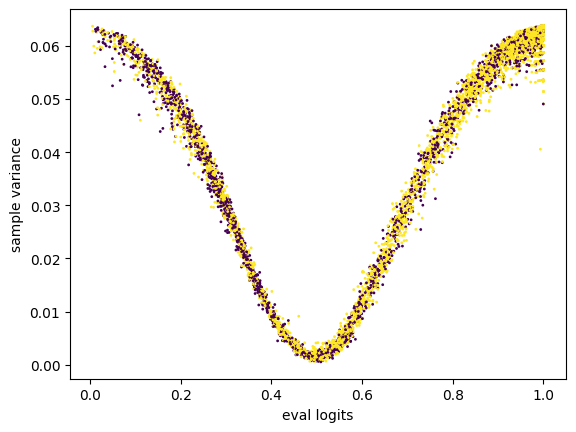

In [13]:
plt.scatter(eval_logits, dropout_var, c=correct_labels.to(float), s=1)
plt.xlabel('eval logits')
plt.ylabel('sample variance')

Very low sample variance at the 50% mark, increasing with distance from 50%

Text(0, 0.5, 'dropout samples')

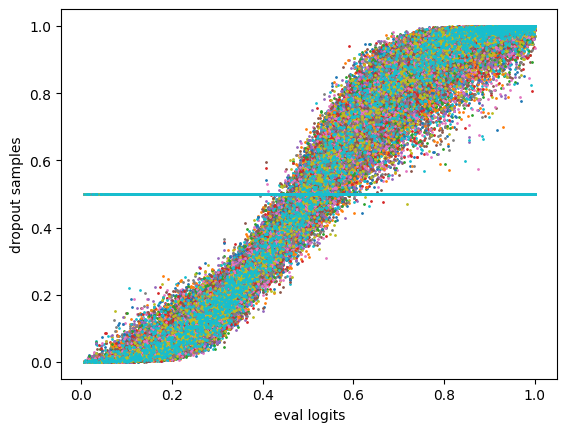

In [14]:
for i in range(50):
    plt.scatter(eval_logits, samples[i], s=1)
plt.xlabel('eval logits')
plt.ylabel('dropout samples')

#plt.plot(np.linspace(0,1, 50), 0.5*np.ones(50), 'k')
#plt.plot(0.5*np.ones(50), np.linspace(0,1, 50), 'k')

In [15]:
# Plotting utilities
def analyze_model2(model, dataset):
    analysis = pd.DataFrame([
        {'pred': model( dataset['activity'][i:i+1]).item(),
         'correct_cls': int((dataset['gts'][i] == dataset['predictions'][i].mode().values).item())
            }
        for i in range(len(dataset['activity']))
    ])
    analysis['binary_pred'] = (analysis['pred'] >= 0.5).astype(int)
    analysis['correct_analysis'] = (analysis['correct_cls'] == analysis['binary_pred']).astype(int)
    
    return analysis


def make_row(analysis, name, subfig):
    subfig.suptitle(f'{name} data')
    axs = subfig.subplots(nrows=1, ncols=2)
    analysis.hist(column='correct_analysis', density=True, ax=axs[0])
    sns.histplot(analysis, x='correct_analysis', hue='correct_cls', 
        multiple='dodge', stat='proportion', common_norm=False, discrete=True, 
        shrink=0.8, ax=axs[1] 
    )


def make_plots2(model, train_data, test_data, suptitle=''):
    train_analysis = analyze_model2(model, train_data)
    test_analysis = analyze_model2(model, test_data)
    fig = plt.Figure(layout='constrained', figsize=(6,7))
    subfigs = fig.subfigures(nrows=2, ncols=1)
    fig.suptitle(suptitle)
    make_row(train_analysis, 'Train', subfigs[0])
    make_row(test_analysis, 'test', subfigs[1])

    display(fig)

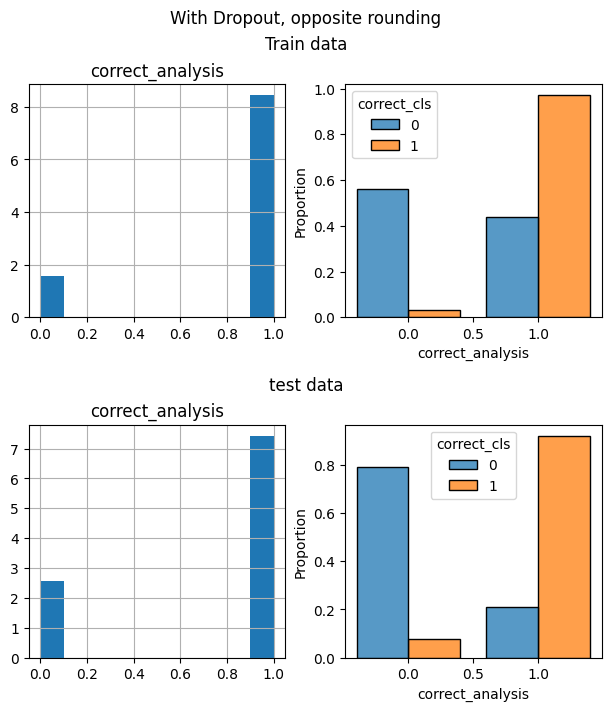

In [16]:
from src.analysis.activity_analysis import DeepSets
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')

make_plots2(model, activity_data_val, activity_data_test, f'With Dropout, opposite rounding')

The rounding 0.5 logit is _entirely_ responsible for the flip behavior.

__In summary:__

 1. I turned dropout off in the phi network, kept in the rho network. Same behavior.
 2. I looked at the logit outputs from the this network with and without dropout. I turns out that the dropout behavior is entirely cause by a set of datapoints that concentrate under dropout at logit=0.5 exactly. Treating this a positive vs negative swings the behavior.
 3. The same occurs for ground truth negative points.

It seems that the network is mapping the 'abnormal' points to exactly the classification boundary.

In [17]:
model.rho.net[7].p=0.

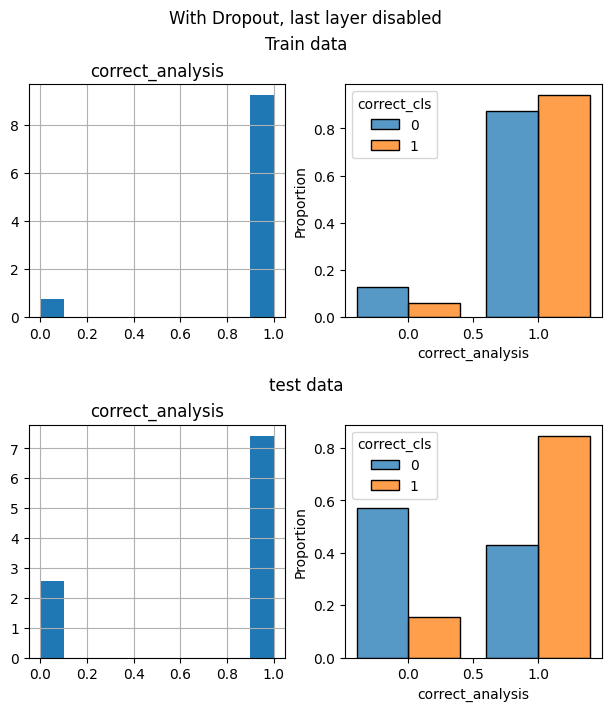

In [20]:
make_plots(model, activity_data_val, activity_data_test, f'With Dropout, last layer disabled')

- Turning last-layer dropout off is sufficient to eliminate the behavior entirely.

This demonstrate that the output 'swapping' was the result of dropout producing outputs at 0 -> 0.5 logits -> swaps depending on how 0.5 is interpreted.  

#### Another interesting point that is raised by the histograms:

Why are there so many output logits clustered at 1? Does this correspond to singly vs multiply decoded outputs?

In [28]:
large_logits = (eval_logits > 0.96)
print(large_logits.to(float).mean())

tensor(0.5115, dtype=torch.float64)


^ more than 50%

In [51]:
num_unique = torch.tensor( [len(row.unique()) for row in activity_data_test['predictions'] ])
logit_table = pd.DataFrame({'large_logits': large_logits.to(int), 'correct_labels': correct_labels.to(int),
                            'num_unique': num_unique})
logit_table['multiple_outs'] = (logit_table['num_unique'] > 1).astype(int)

In [52]:
logit_table

,large_logits,correct_labels,num_unique,multiple_outs
0,0,1,1,0
1,0,0,1,0
2,1,1,1,0
3,0,1,1,0
4,0,1,1,0
...,...,...,...,...
9995,0,1,1,0
9996,0,1,1,0
9997,1,0,1,0
9998,0,1,1,0


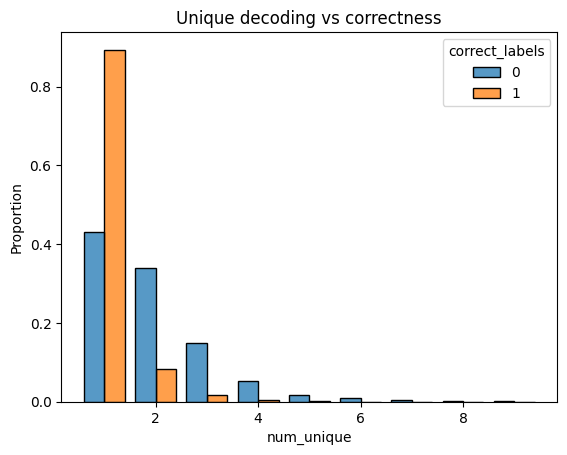

In [90]:
sns.histplot(logit_table, x='num_unique', hue='correct_labels', 
    multiple='dodge', stat='proportion', common_norm=False, discrete=True, 
    shrink=0.8
)
_=plt.title('Unique decoding vs correctness')

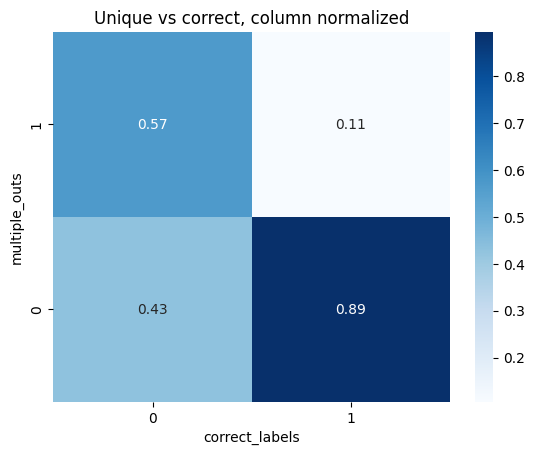

In [89]:
ct = pd.crosstab(logit_table['multiple_outs'], logit_table['correct_labels'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
_=plt.title('Unique vs correct, column normalized')

Again, I will note that this is a stronger effect than the previous analysis.

<Axes: xlabel='num_unique', ylabel='Proportion'>

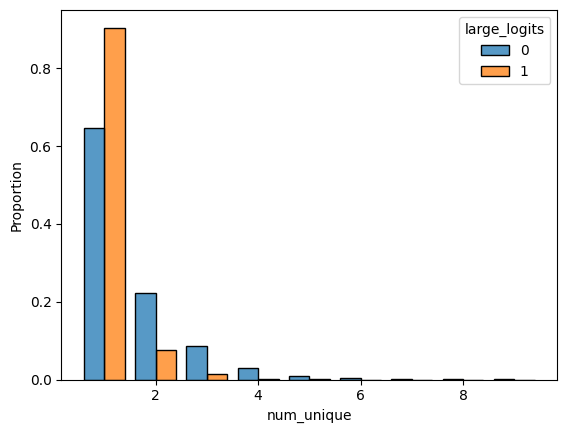

In [68]:
sns.histplot(logit_table, x='num_unique', hue='large_logits', 
    multiple='dodge', stat='proportion', common_norm=False, discrete=True, 
    shrink=0.8
)

Doesn't seem like a that strong of a signal.

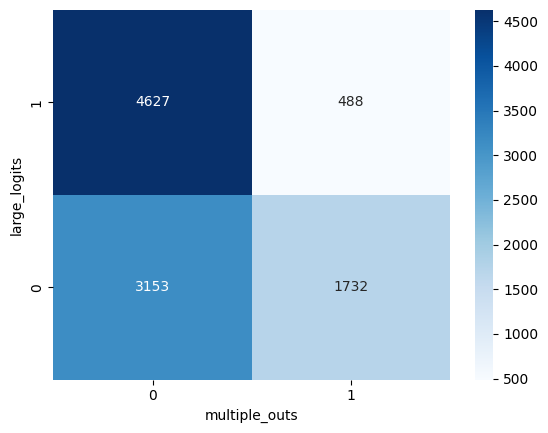

In [94]:
ct = pd.crosstab(logit_table['large_logits'], logit_table['multiple_outs'])
_=sns.heatmap(ct.iloc[::-1], annot=True, fmt='d', cmap='Blues')

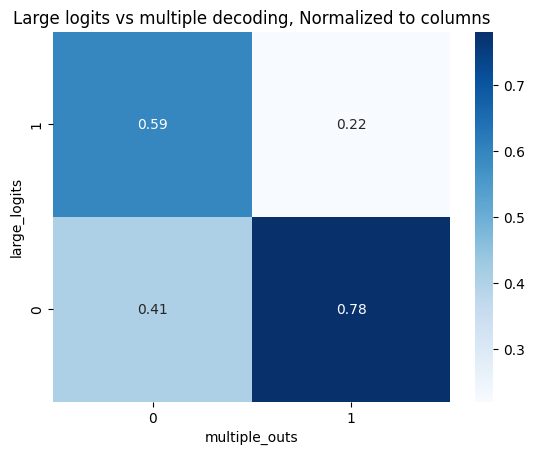

In [97]:
ct = pd.crosstab(logit_table['large_logits'], logit_table['multiple_outs'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
_=plt.title('Large logits vs multiple decoding, Normalized to columns')

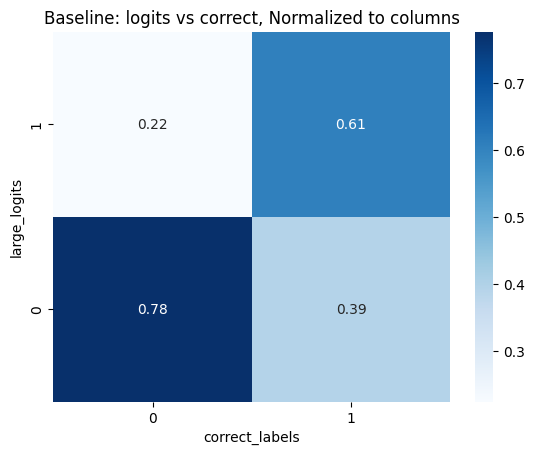

In [93]:
ct = pd.crosstab(logit_table['large_logits'], logit_table['correct_labels'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
_=plt.title('Baseline: logits vs correct, Normalized to columns')

78% of multiple output cases are spread over range < 0.96, compared to 41% of cases with single decoded outputs.
However, this is matched fairly exactly by correspondence to correct labels. 

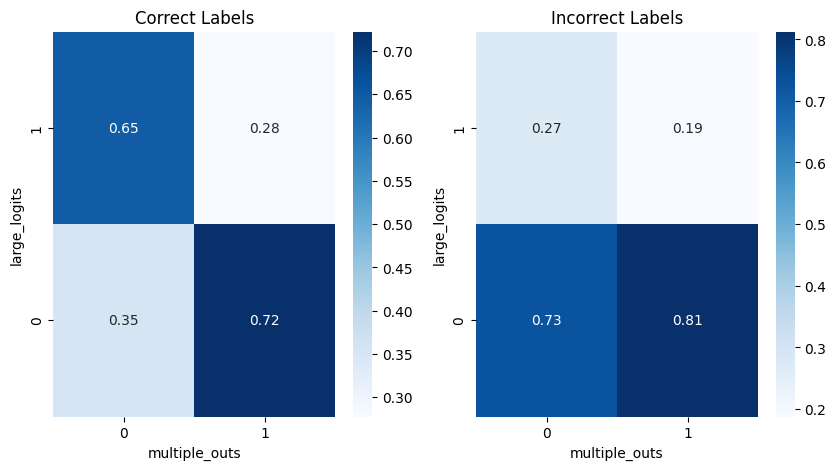

In [109]:
figsize(10,5)
plt.subplots(1,2)

plt.subplot(1,2,1)
filtered_table = logit_table[ logit_table['correct_labels'] == 1]

ct = pd.crosstab(filtered_table['large_logits'], filtered_table['multiple_outs'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
_=plt.title('Correct Labels')

plt.subplot(1,2,2)
filtered_table = logit_table[ logit_table['correct_labels'] == 0]

ct = pd.crosstab(filtered_table['large_logits'], filtered_table['multiple_outs'], normalize='columns')
sns.heatmap(ct.iloc[::-1], annot=True, fmt='.2f', cmap='Blues')
_=plt.title('Incorrect Labels')


In [110]:
import statsmodels.api as sm

# Create a 2x2x2 contingency table
# Order: (stratifier, var1, var2)
table = sm.stats.StratifiedTable.from_data('correct_labels', 'multiple_outs', 'large_logits', logit_table)

print(table.summary())

                   Estimate   LCB    UCB  
------------------------------------------
Pooled odds           0.133   0.119  0.148
Pooled log odds      -2.020  -2.132 -1.907
Pooled risk ratio     0.517               
                                          
                 Statistic P-value 
-----------------------------------
Test of OR=1      1503.585   0.000 
Test constant OR    74.536   0.000 
                        
------------------------
Number of tables     2  
Min n             4885  
Max n             5115  
Avg n             5000  
Total n          10000  
------------------------


There is generally an association between single outputs and large logits, but it does vary between correct and incorrect labels. Notably, incorrect labels still show many fewer large logits when there are single decodings.

Interesting to check out, not sure what else to get from it.

#### Conclusion: this was a bug.

The behavior is entirely due to dropout in the last layer. I've now removed this, so the previous plots are no longer reproducible with the current code."

I do think that the anomaly detection approach might still be promising. Of course, that _assumes_ that the image noise does not make all points look anomalous. This is probably a more general consideration with the approach overall: does abnormality detection generalize to the noisy data? More specifically, can we learn a way to make cls distributions 'normal' (using only uncorrupted data) that still works on corrupted input spaces?

### Paths forward:

Before moving forward, it is worth thinking a bit about what I'm trying to get out of this analysis. There are actually two different objectives with two different paths forward.
1. How strong of a signal about network correctness can I find?
   - this lends itself to the simplest approaches, random forests, gradient boosting, which can find and boost the weak signals to get good performance.
2. How can I use the signals that I have to modify adapatation procedures, etc.
   - this lends itself to neural networks, which can produce gradients. In that sense, a detection network _is_ useful, in that we can just use the signal from the detection network directly for gradients.
  
Currently, I feel like I should first check for the signal using simple methods before trying to use a more complex network for this.

In [128]:
from sklearn.metrics import f1_score, precision_score, recall_score
model = DeepSets.load_from_checkpoint('./dropout_0phi.ckpt').to('cpu')
model = model.eval()

eval_logits = model.forward(activity_data_test['activity']).detach()
predictions = (eval_logits > 0.5).to(int)
correct_labels = (activity_data_test['predictions'].mode().values == activity_data_test['gts']).to(int)



In [145]:
print('F1: ', f1_score(correct_labels, predictions))
print('precision: ', precision_score(correct_labels, predictions))
print('recall: ', recall_score(correct_labels, predictions))

F1:  0.8321902149062643
precision:  0.8159344178301524
recall:  0.8491069048253799


These stats make the classifier look pretty good. However, the key issue is that we _actually_ want to detect negatives well.

In [146]:
print('F1: ', f1_score(1 -correct_labels, 1-predictions))
print('precision: ', precision_score(1 -correct_labels, 1-predictions))
print('recall: ', recall_score(1 -correct_labels, 1-predictions))

F1:  0.4523555745043701
precision:  0.483812129502964
recall:  0.4247397918334668


### Self-supervised model, with gradient boosting classifier

1. Initial results showed that, using UMAP + xgboost I could find a classifier with
   - ~65% accuracy overall and on each subset
   - auROC ~74%
   - However, the feature extraction network showed 100% validation accuracy after the first train epoch.
   - Leads me to believe that the contrastive learning is not learn very useful representations: it is too easy, and fairly trivial mappings are fine, disentangled later by the UMAP + xgboost, but only poorly.

#### Data setup

In [2]:
from src.models.activity_analysis import DeepSetsFoundation

W1222 12:22:15.329000 28425 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


In [3]:
activity_data_val = torch.load('../activity_analysis/2025-12-21_14_23_08_data_gen/activity_data_val.pt')
activity_data_test = torch.load('../activity_analysis/2025-12-22_01_44_59_data_gen/activity_data_test.pt')

In [4]:
embedding_model = DeepSetsFoundation.load_from_checkpoint('../activity_analysis/2025-12-22_00_13_16_train/checkpoint/epoch=11-step=3420.ckpt')
embedding_model = embedding_model.to('mps')

In [5]:
activity_train = activity_data_val['activity']
predictions_train = activity_data_val['predictions']
gts_train = activity_data_val['gts']

activity_test = activity_data_test['activity']
predictions_test = activity_data_test['predictions']
gts_test = activity_data_test['gts']

In [6]:
def make_features(model, activity):
    dl = torch.utils.data.DataLoader(activity, batch_size=100)
    
    features = []
    for batch in iter(dl):
        features.append(model(batch.to('mps')))
    
    return torch.concat(features).detach().cpu()

In [7]:
features_train = make_features(embedding_model, activity_train)
targets_train = (predictions_train.mode().values == gts_train).to(int)

features_test = make_features(embedding_model, activity_test)
targets_test = (predictions_test.mode().values == gts_test).to(int)

#### Gradient boosting, first pass



In [8]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [9]:
sample_weights = compute_sample_weight(class_weight='balanced', y=targets_train)
model = XGBClassifier(eval_metric='aucpr', random_state=1,
                     scale_pos_weight=0.3)


In [10]:
model.fit(features_train, targets_train, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
(model.predict(features_test) == targets_test).float().mean()

tensor(0.6078)

In [12]:
(model.predict(features_test) == targets_test)[targets_test == 0].float().mean()

tensor(0.6960)

In [13]:
(model.predict(features_test) == targets_test)[targets_test == 1].float().mean()

tensor(0.5789)

Applying the right scaling to positive vs negative weights, we can, of course trade-off accuracy on positive vs negative sets.

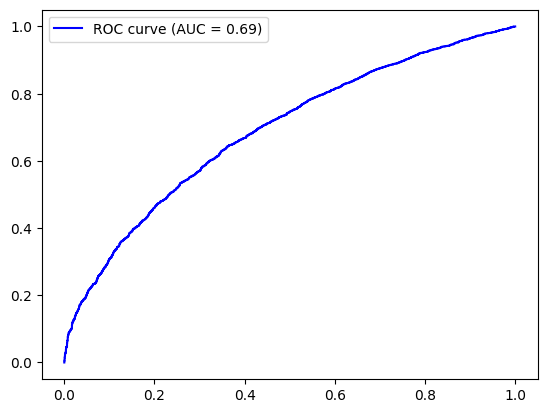

In [14]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = model.predict_proba(features_test)[:, 1]
fpr, tpr, thresholds = roc_curve(targets_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.legend()

This is a fairly poor classifier, 67% auROC, but one with more than 50% accuracy on both positive and negative class examples.

In [15]:
booster = model.get_booster()
scores = list(booster.get_score(importance_type='gain').values())
scores.sort()

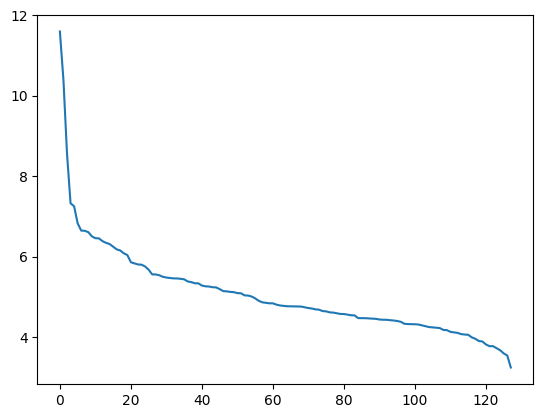

In [16]:
plt.plot(scores[::-1])

#### umap approach

In [17]:
import umap
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Reduce to 10–20 UMAP components
reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(features_train)
X_umap_test = reducer.transform(features_test)

# Train XGBoost on UMAP features
model_umap = XGBClassifier(
    scale_pos_weight=len(targets_train[targets_train==0]) / len(targets_train[targets_train==1]),
    max_depth=5, 
    learning_rate=0.05
)
model_umap.fit(X_umap, targets_train)

probs = model_umap.predict_proba(X_umap_test)[:, 1]
print(f"UMAP AUC: {roc_auc_score(targets_test, probs):.4f}")

/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP AUC: 0.7469


In [18]:
umap_correctness = ((probs > 0.5).astype(int) == targets_test)
print('overall: ', umap_correctness.float().mean())
print('negative: ', umap_correctness[targets_test == 0].float().mean())
print('positive: ', umap_correctness[targets_test == 1].float().mean())

overall:  tensor(0.6613)
negative:  tensor(0.7325)
positive:  tensor(0.6380)


More improvement.

All of this is to say: there is very much so signal there, the trick is pulling it out. Not sure how much more there is to gain by pushing this analysis forward.

#### How small of sets do I need to achieve good accuracy.

Text(0.5, 1.0, 'Features based on the full sets show perfect decoding')

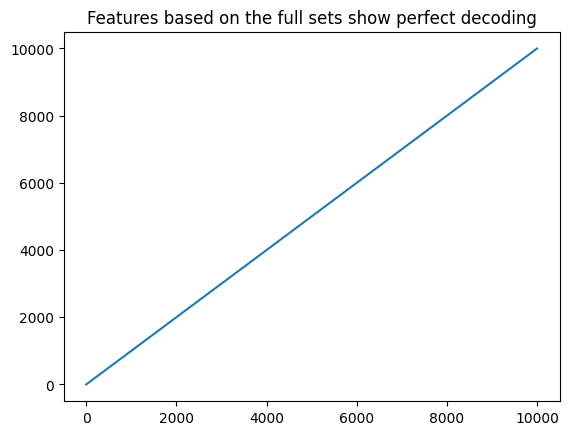

In [8]:
plt.plot(torch.arange(len(features_test)), (features_test @ features_test.T).argmax(1) )
plt.title('Features based on the full sets show perfect decoding')

Perfect decoding with full sets.

Text(0.5, 1.0, 'Features based on the single datapoints show perfect decoding')

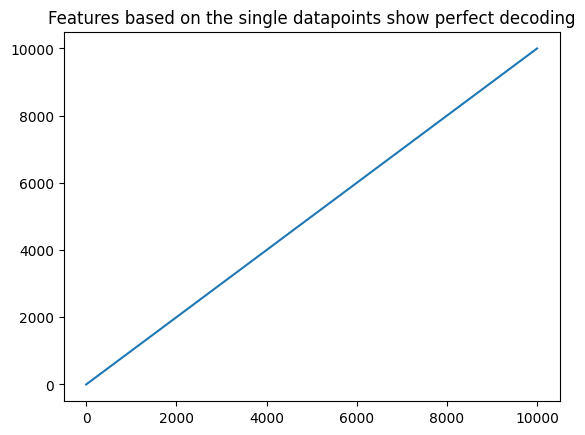

In [9]:
inds = torch.randperm(activity_test.shape[1])[0:1]
subsamples = activity_test[:, inds, :]

subsample_features = make_features(embedding_model, subsamples)

plt.plot(torch.arange(len(subsample_features)), (subsample_features @ subsample_features.T).argmax(1) )
plt.title('Features based on the single datapoints show perfect decoding')

Every datapoint is _sufficient_ to determine where it came from! This contrastive model really gave us nothing but dimensionality reduction...

In [21]:
random_guessing = np.array([(torch.arange(len(z)) == torch.randperm(len(z))).float().mean() for i in range(100)])
print(random_guessing.mean(), random_guessing.var())

0.000107999986 1.09360005e-08


accuracy of 1-dim: 0.00019999999494757503


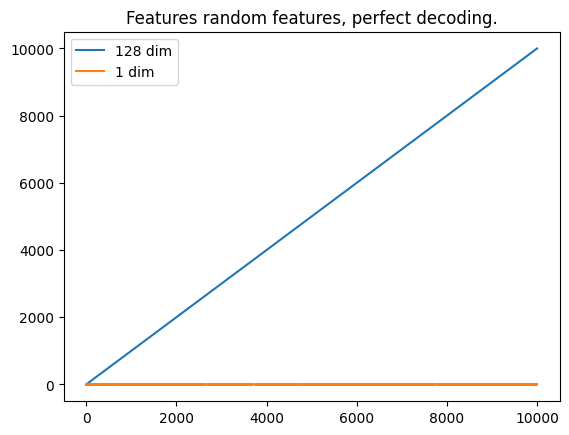

In [22]:
# Random baseline
A = torch.randn(128, 768) / 128**0.5
z = activity_test[:, 0, :] @ A.T
z = torch.nn.functional.normalize(z, dim=-1)

dim= 1
A2 = torch.randn(dim, 768) / 128**0.5
z2 = activity_test[:, 0, :] @ A2.T
z2 = torch.nn.functional.normalize(z2, dim=-1)

print(f'accuracy of {dim}-dim: {(torch.arange(len(z2)) == (z2 @ z2.T).argmax(1)).float().mean()}')

plt.title('Features random features, perfect decoding.')
plt.plot(torch.arange(len(z)), (z @ z.T).argmax(1), label='128 dim')
plt.plot(torch.arange(len(z)), (z2 @ z2.T).argmax(1), label=f'{dim} dim')

plt.legend()

In [26]:
def random_reduction_samples(dim):
    accuracies = []
    for sample in tqdm(range(200)):
        A2 = torch.randn(dim, 768) / 128**0.5
        z2 = activity_test[:, 0, :] @ A2.T
        z2 = torch.nn.functional.normalize(z2, dim=-1)
        
        accuracy = (torch.arange(len(z2)) == (z2 @ z2.T).argmax(1)).float().mean()
        accuracies.append(accuracy)
    
    return np.array(accuracies)

random_accuracies = {i: random_reduction_samples(i) for i in [1,2,3,4]}

100%|█████████████████████████████████████████| 200/200 [00:29<00:00,  6.79it/s]


In [29]:
results = {k: (float(v.mean()), float(v.var())) for k,v in random_accuracies.items()}

In [30]:
results

{1: (0.00019249998149462044, 6.937498908676787e-10),
 2: (0.36696597933769226, 0.014731165952980518),
 3: (0.9979555010795593, 2.181271611334523e-06),
 4: (0.9999984502792358, 1.4780149326654168e-10)}

This seems to imply a very strong degree of separation between points and perhaps an extremely low intrinsic dimensionality.

Text(0.5, 1.0, 'Single point activity, no learned representation.')

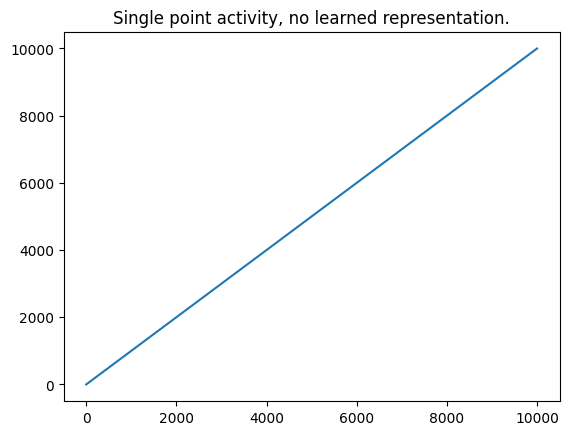

In [55]:
subsamples = activity_test[:, 0, :]
subsamples = torch.nn.functional.normalize(subsamples)
plt.plot(torch.arange(len(subsamples)), (subsamples @ subsamples.T).argmax(1) )
plt.title('Single point activity, no learned representation.')

To summarize, single point activity is sufficient to distinguish classes, with no transformation, or with random dimensionality reduction, even with dimensionality as small as 3 producing almost perfect accuracy.

This means that the feature embeddings are not really extracting anything of value.

Note also that the fact that single datapoint, random features are so important probably means that the classifiers are extracting nothing but location! Nothing about the spread.

#### What can we extract based on the predictions alone?

In [135]:
def features_encoding(predictions):
    outs = []
    for row in predictions:
        unique = row.unique()
        present = torch.zeros(200)
        present[unique] = 1
        out_row = {str(i): v.item() for i,v in enumerate(present)}
        out_row.update(count=len(unique))
        outs.append(out_row)

    return pd.DataFrame(outs)

In [136]:
predictions_train = activity_data_val['predictions']
predictions_test = activity_data_test['predictions']

features_train = features_encoding(predictions_train)
features_test = features_encoding(predictions_test)

In [137]:
from xgboost import XGBClassifier

sample_weights = compute_sample_weight(class_weight='balanced', y=targets_train)
model = XGBClassifier(eval_metric='aucpr', scale_pos_weight=0.3)

model.fit(features_train, targets_train, sample_weight=sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [138]:
(model.predict(features_train) == targets_train).float().mean()

tensor(0.3714)

In [139]:
(model.predict(features_test) == targets_test).float().mean()

tensor(0.3672)

In [140]:
(model.predict(features_test) == targets_test)[targets_test == 0].float().mean()

tensor(0.9603)

In [141]:
(model.predict(features_test) == targets_test)[targets_test == 1].float().mean()

tensor(0.1730)

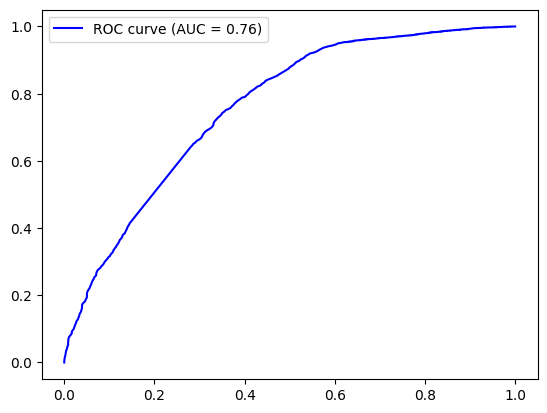

In [142]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = model.predict_proba(features_test)[:, 1]
fpr, tpr, thresholds = roc_curve(targets_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.legend()

About the same performance, but using only the decodings.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

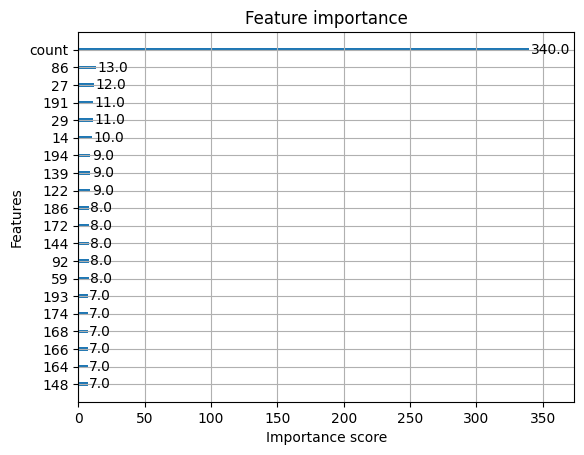

In [143]:
from xgboost import plot_importance
plot_importance(model, max_num_features=20)

Ok. This is as I was thinking. Almost all of the information is in the number of outputs, with small contribution from classes that are imbalanced (I'm guessing these appear frequently as false positives).

AUC is still fairly low, but it beats pretty much every activity based model that I have yet tried. This indicates to me that _there is signal there_. The challenge remains finding it.

#### How much does the context impact decoded values

The signal may be in the other image tokens, which _are_ passed forward to the classifier and therefore are seen by the decoding but not by looking at the raw CLS token distribution.

In [3]:
from src.models.TTA_model import ClassifierWithTTA
from src.data.image_data import balanced_train_subsets
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')
activity_data_test = torch.load('../activity_analysis/2025-12-22_01_44_59_data_gen/activity_data_test.pt')
print((activity_data_test['gts'] == image_data[:][1]).all())

/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


tensor(True)


In [48]:
cls_model = ClassifierWithTTA.from_pretrained('../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best')

Loading weights from local directory


In [4]:
all_tokens = []
def recording_hook(module, input, output):
    all_tokens.append(output.detach().clone().cpu())

handle = cls_model.embedding.vit.layernorm.register_forward_hook(recording_hook)

In [5]:
_=cls_model.forward(image_data[0:1][0])
print(image_data[0:1][1])

tensor([0])


In [6]:
activity = all_tokens.pop()

In [7]:
def decode_token(token, model, base_activity):
    x = base_activity.clone()
    x[0,0,:] = token
    
    x = model.classifier.vit.encoder(x).last_hidden_state
    x = model.classifier.vit.layernorm(x)[:, 0, :]
    logits = model.classifier.classifier(x)
    return logits.argmax(1)

100%|████████████████████████████████████| 10000/10000 [01:35<00:00, 104.32it/s]


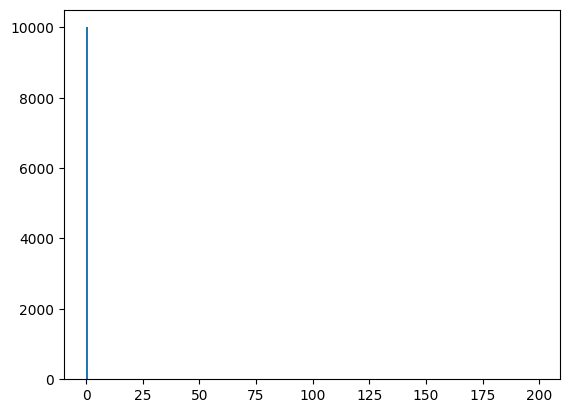

In [8]:
decoded = []
for i in tqdm(range(10000)):
    token = activity_data_test['activity'][i][1]
    decoded.append(decode_token(token, cls_model, activity).item())

_=plt.hist(decoded, bins=range(200))

Here, classification output is entirely determined by the image tokens, not the cls token.

In [9]:
print(len(all_tokens))

0


In [10]:
random_samples = []
for sample in tqdm(range(10000)):
    i = torch.randint(10000, (1,))[0]
    j = torch.randint(10000, (1,))[0]

    image, image_label = image_data[i:i+1]
    _=cls_model.forward(image)
    full_encoding = all_tokens.pop(-1)

    token = activity_data_test['activity'][j,torch.randint(50, (1,))[0], :]
    token_label = activity_data_test['gts'][j]

    decoded = decode_token(token, cls_model, full_encoding)
    
    row = {'image_activity_id': image_label.item(), 'cls_token_id': token_label.item(), 'decoded': decoded.item()}

    random_samples.append(row)

random_samples = pd.DataFrame(random_samples)

100%|█████████████████████████████████████| 10000/10000 [12:50<00:00, 12.97it/s]


<Axes: xlabel='image_activity_id', ylabel='decoded'>

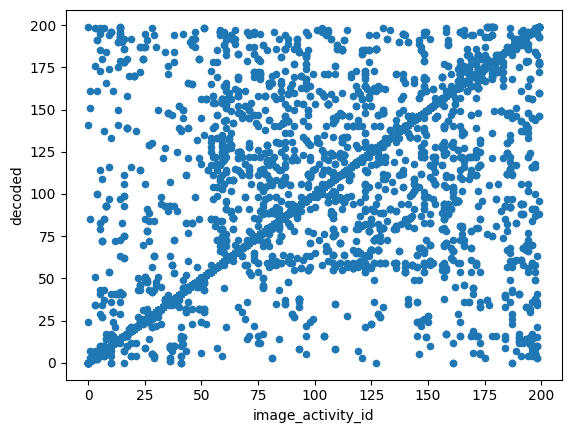

In [15]:
random_samples.plot.scatter(x='image_activity_id', y='decoded')

In [18]:
print((random_samples['image_activity_id'] == random_samples['decoded']).mean())

0.7365


<Axes: xlabel='cls_token_id', ylabel='decoded'>

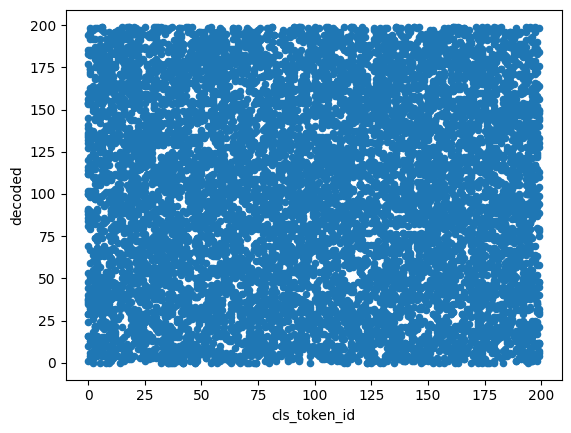

In [16]:
random_samples.plot.scatter(x='cls_token_id', y='decoded')

In [19]:
print((random_samples['cls_token_id'] == random_samples['decoded']).mean())

0.0065


Image tokens domainate but don't entirely decide the decoded outputs. Class tokens have almost no relationship to decoded outputs.

Finding: The image tokens, which _are_ passed forward into the transformer classifier, are a major factor in determining the decoded output, while CLS tokens have almost no influence. In other words, the information is _not yet_ gathered into the CLS token here to the point of having much impact on the overall signal.


### Tying this in a bow: randomizing the CLS token at various points in the network:

In [3]:
cls_model = ClassifierWithTTA.from_pretrained('../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best')
image_data, _ = balanced_train_subsets(train_fraction=1, split='valid')

cls_model = cls_model.to('mps')

Loading weights from local directory


/Users/luke/Documents/activeProjects/TTA_working/analysis/../src/data/image_data.py:28: UserWarning: You are not fetching train data
  warnings.warn("You are not fetching train data")


In [7]:
def randomize_layer_cls_token(model, layer_name, layer_ind, dataset, debug=False, add_hook=True):
    def randomization_hook(module, input, output):
        if debug:
            print('in hook')
        copied_output = output.clone()
        batch, tokens, dims = copied_output.shape
        
        #ind_perm = torch.randperm(batch)
        copied_output[:, 0, :] = torch.randn(batch, dims)
        #copied_output[ind_perm, 0, :]
        
        return copied_output


    layer_registry = {'embedding': model.embedding.vit.encoder.layer,
                      'classifier': model.classifier.vit.encoder.layer
                     }        

    handle = layer_registry[layer_name][layer_ind].register_forward_hook(randomization_hook)


    dl = torch.utils.data.DataLoader(dataset, batch_size=32)
    outputs = []
    for batch in tqdm(iter(dl)):
        images, labels = batch
        preds = model.forward(images.to('mps')).logits.argmax(1).cpu()
        #print((preds.cpu() == labels).float().mean())

        outputs.append(preds.cpu() == labels)

    handle.remove()
    return torch.concat(outputs)

In [8]:
randomized_ckpt = '../experiments_base/2025-12-19(06:13:59)-randomized_retrain/checkpoints/full/best'

In [15]:
results = []
for embedding, layer in [('embedding', 0), ('embedding', 11), ('classifier', 0), ('classifier', 1)]:
    cls_model = ClassifierWithTTA.from_pretrained(randomized_ckpt)
    cls_model = cls_model.to('mps')
    
    accuracy = randomize_layer_cls_token(cls_model, embedding, layer, image_data, debug=False).float().mean()

    results.append({'layer': f'{embedding}_{layer}', 'accuracy': accuracy})
    

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [00:58<00:00,  5.34it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [00:58<00:00,  5.32it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [00:58<00:00,  5.33it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [00:59<00:00,  5.24it/s]


In [16]:
results = pd.DataFrame(results)

In [19]:
results['accuracy'] = results['accuracy'].map(lambda x: x.item())

Text(0.5, 1.0, 'Accuracy after randomizing CLS tokens in a layer')

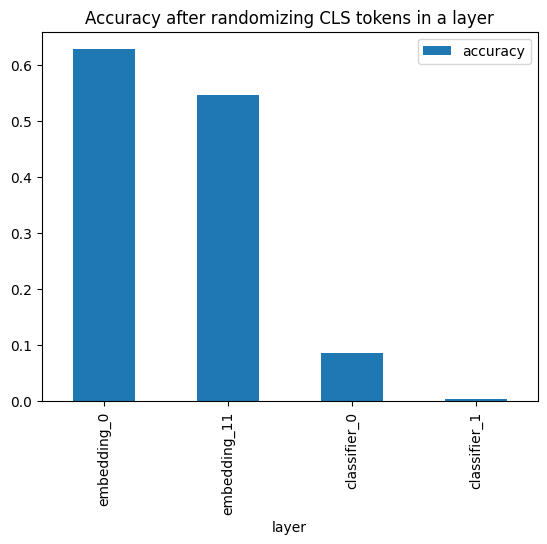

In [21]:
results.plot.bar(x='layer', y='accuracy')
plt.title('Accuracy after randomizing CLS tokens in a layer')

Note that the baseline accuracy is around 75%.

Overall, this is exactly the result that I thought it would be: moving up the network, we see more disruption from CLS token randomization. In particular, the classifier layers contain a lot of information about the class, while embedding layers contain little class information.

Sidenote: The embedding layer shows more performance degredation than the previous result, sampling activity. Possible explainations: the randomization is more extreme than before, the fact that we are randomizing this before batch norm


In [27]:
deterministic_ckpt = '../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/0/checkpoints/full/best'

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.78it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:02<00:00,  4.99it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:02<00:00,  4.98it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:02<00:00,  4.97it/s]


Text(0.5, 1.0, 'Accuracy degredation with deterministic CLS tokens')

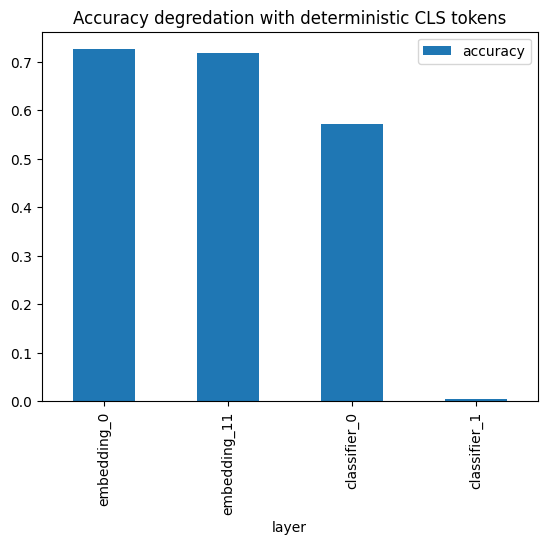

In [29]:
det_results = []
for embedding, layer in [('embedding', 0), ('embedding', 11), ('classifier', 0), ('classifier', 1)]:
    cls_model = ClassifierWithTTA.from_pretrained(deterministic_ckpt)
    cls_model = cls_model.to('mps')
    
    accuracy = randomize_layer_cls_token(cls_model, embedding, layer, image_data, debug=False).float().mean()

    det_results.append({'layer': f'{embedding}_{layer}', 'accuracy': accuracy.item()})

det_results = pd.DataFrame(det_results)
det_results.plot.bar(x='layer', y='accuracy')
plt.title('Accuracy degredation with deterministic CLS tokens')

Huh. This is not what I expected at all. Randomization has _even less_ impact for the embedding, and doesn't impact much in the first layer of classifier either. Possible explaination: there are less complex dynamics to learn with a fixed CLS token -> less layers matter.

Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:00<00:00,  5.20it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:00<00:00,  5.19it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:00<00:00,  5.18it/s]


Loading weights from local directory


100%|█████████████████████████████████████████| 313/313 [01:05<00:00,  4.80it/s]


Text(0.5, 1.0, 'Previous training run, random')

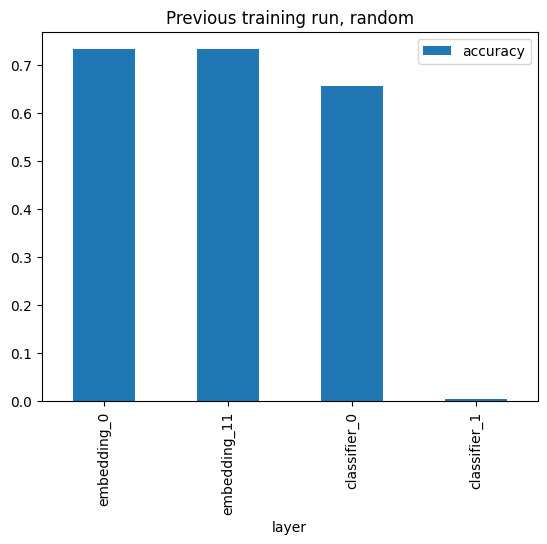

In [32]:
prev_ckpt = '../experiments_base/sweeps/2025-11-13(16:04:10)-base_training/1/checkpoints/full/best'
prev_results = []
for embedding, layer in [('embedding', 0), ('embedding', 11), ('classifier', 0), ('classifier', 1)]:
    cls_model = ClassifierWithTTA.from_pretrained(prev_ckpt)
    cls_model = cls_model.to('mps')
    
    accuracy = randomize_layer_cls_token(cls_model, embedding, layer, image_data, debug=False).float().mean()

    prev_results.append({'layer': f'{embedding}_{layer}', 'accuracy': accuracy.item()})

prev_results = pd.DataFrame(prev_results)
prev_results.plot.bar(x='layer', y='accuracy')
plt.title('Previous training run, random')

Oddly more similar to the deterministic, previous model. These both used more training points and dropout. Probably that's the answer networks trained with dropout are more robust to CLS token randomization, because the already expect random data.


## Summary:

- I have been unsuccessful in extracting much signal from the distributions of CLS tokens that is not present in individual CLS tokens.

- I also find that the image tokens, which _are_ passed forward into the transformer classifier, are a major factor in determining the decoded output, while CLS tokens have almost no influence. In other words, the information is _not yet_ gathered into the CLS token here to the point of having much impact on the overall signal.

- This seems to me to be strong evidence that I'm looking in the wrong place. CLS token distribution in the middle of the network looks insufficient to act as a 'certainty' score or determine much about whether the network will be correct or not.

- Randomization of CLS tokens at various points through out the network confirms this: the accuracy falls 10% when the encoder is randomized, by almost to zero when the classifier is randomized.